# Lesson169 · Scaling laws & open questions

Default: portable CPU-only full saved-evidence replay; Python3+NumPy. No downloads or cloud calls. TierB real relational evidence; synthetic checks only illustrate mechanics. PROVIDED code is complete; TODO contracts drive the audit; CHECK gives immediate feedback; EXIT requires your written defense. Fresh inference is a separate opt-in lane.

**The skill:** decide what a scaling curve actually supports, then turn its missing evidence into a testable research question.

**Reading route.** Identify the axis being changed, work through the doubling example, then inspect the measured curves. Finish by choosing one unanswered question for the gap template. Use a separate session for the complete notebook replay and written defense.

[Lesson 168](https://avistian.github.io/relational/lessons/0168-cross-database-generalization.html) added a second database at a fixed budget of 512 labeled examples. It left a different question unanswered: **what changes when the model can read more labeled context?** This lesson completes that axis before asking what we still do not know about pretraining scale. That distinction protects the mission: evidence for useful relational models must survive a skeptical comparison.

**Prerequisites, restated:** a *support set* is the labeled training examples supplied to an in-context predictor; a *query* is an example whose target must be predicted. *Frozen weights* means no optimizer updates on the target task. A *checkpoint* is a saved set of model parameters. *DFS* (Deep Feature Synthesis) builds a flat feature matrix from related tables using aggregations. A *seed* fixes a reproducible support draw; ten seeds are ten draws on the same database, not ten new databases.

Recall: why are ten support seeds not ten databases? Why is zero-gradient inference not zero-label inference?

## 1 · “Bigger” has several meanings

The [2025 RDL survey, §5.2](https://arxiv.org/html/2506.16654v1#S5.SS2) argues for models that combine reusable relational structure, heterogeneous attributes and temporal reasoning. It motivates a research direction; it does not give a fitted relational scaling law. We use it as historical framing and the version-pinned [RDB-PFN v5 experiment](https://arxiv.org/html/2603.03805v5#A1.SS3) as measurable evidence.

| Axis increased | What changes | What must be controlled to isolate it? |
|---|---|---|
| Inference context K | Labeled target examples read by a frozen predictor | Checkpoint, task, feature pipeline, test queries, support sampler |
| Parameter count P | Number of learned model coefficients | Training data, optimization and evaluation; declare compute allocation |
| Pretraining data D | Training examples consumed before target inference | Model capacity, data mix, duplicates, training budget and stopping rule |
| Schema diversity S | Variety of table/link structures during pretraining | Total rows/tokens, domain mix, schema definition and target exposure |
| Compute C | Operations or resource budget spent | Hardware/precision for timings; architecture and data allocation for learning |

Rows are not independent units of schema diversity: copying one database a hundred times changes row count without adding a new schema. Parameters, data and compute also interact; holding training compute fixed answers a different question from training every model to convergence. Define the estimand—the quantity your comparison is intended to measure—before choosing the sweep.

<figure class="route-figure" tabindex="0">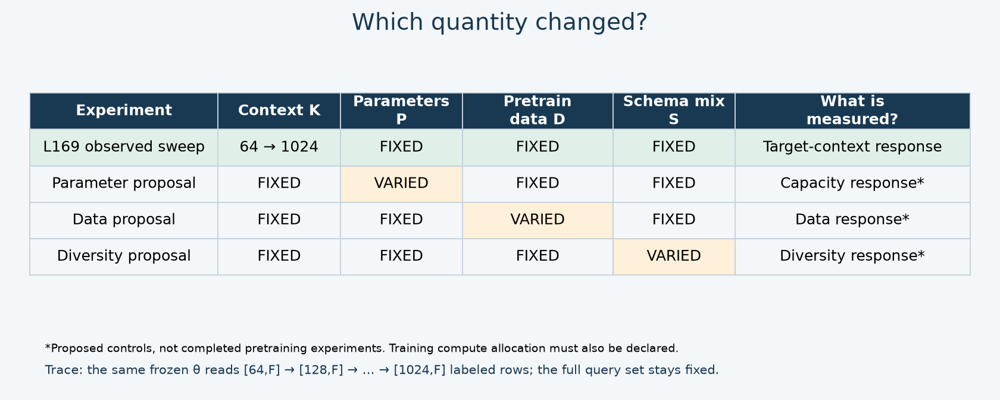<figcaption>Only context changes in the observed sweep. The parameter, data and diversity rows are proposed experiments with additional compute controls required.</figcaption></figure>

**Worked trace.** Imagine weights θ with 700,000 coefficients and a fixed query matrix. At K=64, the predictor reads 64 feature rows and their labels. At K=128, it reads 128. θ is identical in both calls. We have changed target-time information and computation, not the number of pretrained parameters or pretraining examples. The number here is illustrative; the experiment loads and hashes the released weights.

## 2 · A response curve is not yet a scaling law

> **In plain terms.** A curve records what happened at the sizes we tried. A proposed scaling law goes further: it predicts how the outcome should change with size. Testing that prediction at sizes left out of fitting is part of the evidence it needs.

A response curve plots a measured outcome against an intervention. A scaling law is a proposed quantitative relationship that remains useful across a declared range. A common *illustrative* form is **L(x) = L∞ + A·x^(−α)**: L is a loss, x a positive scale variable, L∞ an assumed limiting loss, A a positive amplitude and α a positive exponent. Doubling x multiplies the excess loss L−L∞ by 2^(−α). If α=1/2, an excess loss of .10 becomes about .0707. This is arithmetic under an assumed model, not a fitted law for relational databases.

Why not fit that equation to any five points? The estimated slope depends on the assumed floor; a different floor can change the exponent substantially. Five noisy points over a short range can fit several functional forms. A defensible law needs a named metric, controlled axes, uncertainty, checks against alternative fits, and predictions checked on held-out scales and tasks. An extrapolation predicts outside the observed range; a smooth line inside a chart does not validate it.

Our metric is **AUROC**, the probability that a random positive gets a higher score than a random negative, giving ties half credit. Higher is better. AUROC measures ranking rather than calibrated probabilities. We report AUROC directly; substituting 1−AUROC for a training loss would add an untested modeling assumption. We do not fit or claim a pretraining exponent here.

Predict before reading: five context sizes with fixed weights can measure a context response. Explain why a parameter exponent is not identified.

## 3 · The complete selected reproduction

[RDB-PFN v5 Appendix A.3 and Tables 6–10](https://arxiv.org/html/2603.03805v5#A6) evaluate contexts **64, 128, 256, 512, 1024** over ten support seeds. We select two tasks and three released models while retaining every size, seed and test query within that selection.

- **F1 / driver-dnf:** 11,411 training candidates; 702 test queries; 72 released DFS features.
- **Trial / study-outcome:** 11,994 training candidates; 825 test queries; 176 released DFS features.
- **Models:** RDB-PFN, its single-table-pretrained ablation, and TabICLv1.1 with 32 estimators. All receive the same DFS features and support identities for each task/size/seed.
- **Frozen protocol:** released checkpoint hashes, source/data revisions, preprocessing and sampler; no checkpoint search or test-based selection. The ablation changes the pretraining prior, not the inference features.

**300 evaluations = 2 tasks × 5 sizes × 3 models × 10 seeds.** The 60 K=512 evaluations are authenticated evidence reused from Lessons 166/168. The other 240 are fresh evaluations for this lesson. All 229,050 query probabilities are independently rescored, including 183,240 fresh probabilities. This is complete for the selected scope; the paper's other tasks/models and fresh pretraining remain unrun.

### The sampler is part of the intervention

For each task and seed, the release hashes a text key into an integer and draws K distinct training indices uniformly. It starts a new generator for each K. **Identical seeds do not make different-size draws nested prefixes.** A doubling changes both the number and the composition of supports. We preserve this published protocol rather than silently replacing it with an additive-support experiment.

At a fixed K, model differences are paired on exactly the same supports. Across K, seed-indexed differences are descriptive contrasts under the released sampler; they are not the causal effect of adding precisely K extra rows to an unchanged support set. The notebook also reports actual support overlaps. A separately declared nested-support experiment would answer that narrower question.

Implement the source-compatible sampler in the first TODO task below.

### Identity and time before scores

Predictions align on complete **(entity ID, query cutoff)** keys. Every training label's outcome window ends before the earliest test query (60 days for F1, 365 for trial). Earlier audits check the exposed MAX timestamps; they do not reconstruct every DFS operation or historical data arrival. The released labels complement the raw task labels on both tasks. We retain the release's semantics; complementing labels and probabilities together preserves AUROC, but complementing only one does not.

Code, data, weights, original receipts and raw predictions are authenticated. Two client RPC cancellations interrupted the main batch. We preserved 225 complete runs from the second attempt, completed nine missing runs, and checked six repeated sentinel results: four RDB-PFN repeats match exactly; two TabICL repeats differ by up to 0.0002791 in probability and 0.00000488 in AUROC. Exact TabICL repeatability is not established; the cause is not isolated. We retain the first completed result per identity, without score-based selection. The combined receipt is explicitly author-assembled from original per-run records; incomplete or duplicate runs are not counted twice. Full DFS regeneration is `NOT_RUN`; historical identity/availability, checkpoint training lineage and exact target-schema exclusion remain `NOT_ESTABLISHED`. Numeric closeness does not resolve these gaps.

## 4 · Read the whole curve, including reversals

<figure class="route-figure" tabindex="0">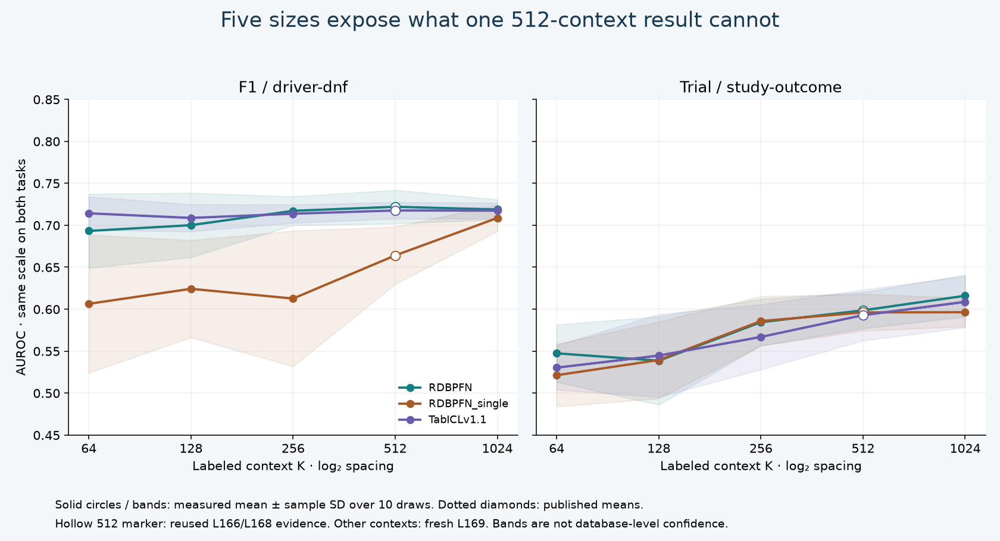<figcaption>Same AUROC scale across both tasks. Solid means and sample SD bands are measured; dotted diamonds are published means. Hollow512 markers are reused evidence.</figcaption></figure>

Each point is a mean over ten support draws; the shaded band is **± one sample standard deviation**, not a confidence interval or uncertainty across databases. The dotted diamonds mark the published means. The hollow measured marker at K=512 denotes reused evidence. Both panels use the same AUROC scale.

| Task / model | K=64 | 128 | 256 | 512 reused | 1024 |
|---|---:|---:|---:|---:|---:|
| rel-f1 / RDBPFN | 0.6932 | 0.7000 | 0.7171 | 0.7219 | 0.7188 |
| rel-f1 / RDBPFN_single | 0.6063 | 0.6242 | 0.6126 | 0.6640 | 0.7086 |
| rel-f1 / TabICLv1.1 | 0.7142 | 0.7087 | 0.7137 | 0.7176 | 0.7173 |
| rel-trial / RDBPFN | 0.5474 | 0.5386 | 0.5844 | 0.5986 | 0.6159 |
| rel-trial / RDBPFN_single | 0.5212 | 0.5393 | 0.5858 | 0.5961 | 0.5963 |
| rel-trial / TabICLv1.1 | 0.5303 | 0.5447 | 0.5669 | 0.5928 | 0.6088 |

On rel-f1, RDB-PFN changes from **0.69318** at 64 to **0.71876** at 1024 (+0.02558 AUROC). On rel-trial, RDB-PFN changes from **0.54736** at 64 to **0.61595** at 1024 (+0.06859 AUROC). **30/30 published-mean comparisons** fall within the predeclared 0.02 AUROC descriptive tolerance. Negative mean doubling contrasts: rel-f1/RDBPFN 512→1024 (-0.00318); rel-f1/RDBPFN_single 128→256 (-0.01161); rel-f1/TabICLv1.1 64→128 (-0.00548); rel-f1/TabICLv1.1 512→1024 (-0.00023); rel-trial/RDBPFN 64→128 (-0.00879). These are measured responses under changing support draws, not evidence for a universal monotonic law.

Baseline is K=64 for the selected task/model. Compare any observed level to that baseline using the live curve output below.512evidence is reused. Other contexts are fresh.

### Compute a gain before explaining it

For a given model, let A(k,s) be its AUROC at context k and seed s. The seed-indexed doubling contrast is Δ(k,s)=A(2k,s)−A(k,s). Average the ten differences; also report their sample SD and the number above zero. For illustrative values [.70,.72] at 64 and [.71,.70] at 128, the differences are [.01,−.02] and the mean is −.005. Averaging can hide a reversal. Two seeds are used only to make the arithmetic visible; the experiment uses ten.

<figure class="route-figure" tabindex="0">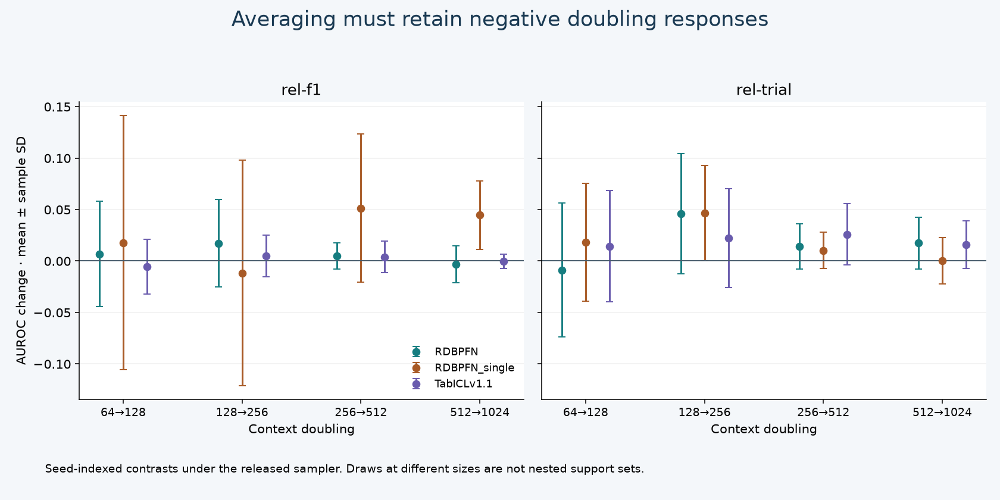<figcaption>Mean AUROC change for each context doubling with sample SD over ten seed-indexed contrasts. Negative gains remain visible; supports across sizes are not nested.</figcaption></figure>

The gain plot retains negative differences. Neither more context nor a relational prior is guaranteed to improve every draw. More support can supply useful evidence, irrelevant examples or a different class mix, while increasing inference cost. This sweep measures the combined response; a mechanism explanation requires an additional controlled ablation. Model-to-model differences at each K are included in the report and notebook.

## 5 · Convert unknowns into experiments

A useful gap is more specific than “scale up.” Name what changes, what remains fixed, the evaluation contract and a result that would contradict the hypothesis.

| Question | Evidence available here | Missing experiment / falsifier |
|---|---|---|
| Does more labeled context improve this checkpoint? | Complete five-size, two-task curves | Replicate on held-out databases; a consistent flat or negative curve challenges broad benefit |
| Do more pretrained parameters improve transfer? | Fixed checkpoints only | Several model sizes with declared compute allocation and matched data; no held-out gain challenges size-only benefit |
| Do more synthetic tasks help? | One released checkpoint per prior | Controlled pretraining-data sweep with repeats; plateau or deterioration challenges monotonic improvement |
| Does schema diversity matter beyond row count? | Reported relational-prior construction; lineage gaps remain | Hold total rows fixed, vary distinct schemas, exclude target schemas; no improvement challenges diversity benefit |
| Can a fitted relation predict outside this range? | Observations only through K=1024 | Freeze candidate fit using smaller scales, evaluate unseen scales/tasks; large systematic errors reject extrapolation |

The first row is substantially measured; the next four are research proposals. They are not claims that no later paper has studied these questions. This is a source-pinned evidence map for this course, not a census of every current result.

Controlled five-level context sweep → CONTEXT_RESPONSE_ONLY. An attempted prediction beyond the range → EXTRAPOLATION_NOT_ESTABLISHED. Other axes here are hypothetical study declarations.

**Prioritize three gaps.** Score each from 1–3 for expected decision value, tractability within a stated budget, and ability to falsify the hypothesis. Explain the score rather than treating the sum as objective truth. A nested-context comparison is accessible with released checkpoints; a parameter/data scaling study needs fresh pretraining and a separate cost estimate. This prepares [Lesson 170's design checkpoint](https://avistian.github.io/relational/lessons/0170-fm-design-checkpoint.html) and the later Year 6 research proposal without requiring optional bridge lessons.

## Lab · Make the evidence map executable

[Student notebook](https://avistian.github.io/relational/labs/0169-scaling-laws-open-questions.ipynb) · [Executed reference notebook](https://avistian.github.io/relational/labs/html/0169-scaling-laws-open-questions.html) · [Reproduction protocol](https://avistian.github.io/relational/labs/l169-reproduction.md) · [Scaling-gap template](https://avistian.github.io/relational/labs/l169-gap-template.md) · [Quick reference](https://avistian.github.io/relational/reference/scaling-laws.html).

The default notebook is a portable CPU-only replay of the complete raw evidence. Three live tasks implement the source-compatible support schedule, complete-grid curve aggregation and conservative claim classifier. Your functions are used by the final audit; missing contexts, duplicated runs and wrong claims must fail. All computation is visible. A separately enabled fresh-inference lane loads the pinned released model source; the managed operator reserves cost before dispatch.

**Exit ticket:** submit a known/unknown table plus a 250–400-word defense of one tractable experiment. State the axis, control variables, target exposure, expected falsifier and budget. Explain why ten seeds do not establish a law across databases. Rubric: 0–2 each for axis separation, protocol, uncertainty, falsifiability and feasibility; target ≥8/10 with no zero. Passing code is author/learner computational evidence; a reviewed written defense is still required for mastery.

Write your own falsifiable next experiment: axis, controls, exposure, uncertainty, falsifier and total cost.

Ask the teacher about any unclear step, or paste your curve interpretation and gap map for feedback. Tomorrow, explain without notes why a K=512 result cannot reveal an exponent for pretraining-data scale.

**Primary reading:** [Dwivedi et al., RDL survey §5.2](https://arxiv.org/html/2506.16654v1#S5.SS2), then [RDB-PFN v5 §6 and Appendix A.3/F](https://arxiv.org/html/2603.03805v5). Read the released sampler beside the paper: [pinned evaluation code](https://github.com/MuLabPKU/RDBPFN/blob/a95378225478daa262b85f180d482da7516b0af6/model_pretrain/src/eval.py).


In [ ]:
# @colab-bootstrap
import os
os.environ.update(OMP_NUM_THREADS="1",OPENBLAS_NUM_THREADS="1",MKL_NUM_THREADS="1")
import base64,hashlib,io,json,zipfile
from pathlib import Path
import numpy as np
P=Path("l169-portable");P.mkdir(exist_ok=True)

## PROVIDED · Authenticate raw evidence
This packet includes all300 complete prediction files, original receipts, prepared task matrices, supports and released source.240runs are fresh L169 evidence;60are reused512-context evidence. The first interrupted batch is excluded.225saved runs from the second attempt plus9tail runs form an explicitly author-assembled receipt; original per-run files are also authenticated. Six diagnostic sentinel reruns (four RDB-PFN exact; two TabICL with small numerical differences) are not counted as new experiment cells.

In [ ]:
encoded='...'
raw=base64.b64decode(encoded)
assert hashlib.sha256(raw).hexdigest()=='38f5a03a422c2bc0be3b75c076674f1e30646f7ccf99c5d6b23126010946ab5b'
with zipfile.ZipFile(io.BytesIO(raw)) as archive:
    for name in archive.namelist():assert not Path(name).is_absolute() and ".." not in Path(name).parts
    archive.extractall(P)
pins={'files': {'evidence/l166/full-1/RDBPFN-1.json': '77e8144ebf3cf3c0deb2f4567d1169e34487a4da3f8839134687ef48f9988fca', 'evidence/l166/full-1/RDBPFN-1.npz': 'b234f020b1076ea01e1f38dc048e7f3be8aea6dcba21da845d8ca0fca72a7fae', 'evidence/l166/full-1/RDBPFN-2.json': '2f822f19b5416d29c4dc671615e4f0e2533f3a961de3191c392f0465be3a8b0d', 'evidence/l166/full-1/RDBPFN-2.npz': '874bf69e6c96d57e8a93936cd2d2e46c778ded54ae93edd4b8a62516ae62398f', 'evidence/l166/full-1/RDBPFN-3.json': '0ceed06dc7e6f3a85eac3cb1b7dc6bc41a8a45da7a1f6c9b60ce6fabd8aa9a04', 'evidence/l166/full-1/RDBPFN-3.npz': '3f01dd8ca7ffeb66f98aea347ef2592f23e1ba70df6f832a97825ae06b113a4b', 'evidence/l166/full-1/RDBPFN-4.json': 'cfe948de7c172ddcfad41c54a13a84e5ab97934261cb44e86014011005f58e43', 'evidence/l166/full-1/RDBPFN-4.npz': 'ae2ddcbdf66ebac5a196349f54a1f4d34c9df98e8660c97e70829606ab4a8dc9', 'evidence/l166/full-1/RDBPFN-5.json': '19c411b2922a1c5bfb592bcdd9f07deae8e2373599ce813f1f724582dedada75', 'evidence/l166/full-1/RDBPFN-5.npz': '02803816d249ca1f275dfed37870f90992aafcd1d30bc53d3a62f64a6456f93f', 'evidence/l166/full-1/RDBPFN-6.json': '263f55a923e9525f450df5b9748a89085abdc0d9d4b0f90a0e0ac7d07bde061f', 'evidence/l166/full-1/RDBPFN-6.npz': 'aae3b3c774b9cc1364770f2037eba3cbf4a7ed7cd6e543432175e92d8ed3bbd2', 'evidence/l166/full-1/RDBPFN-7.json': '97839b67f58eec186bb86b0a3a22b469d3f799e4f1d9e823d950dac35d044799', 'evidence/l166/full-1/RDBPFN-7.npz': '0e74602505fee5446e8da5d2532dc568f1616fbc6af1608e1c70706e36fdc839', 'evidence/l166/full-1/RDBPFN-8.json': 'bc8b92f11b5ff4e035c77a04b04b8b3e54949e2e6aad170cce5808076e15bed5', 'evidence/l166/full-1/RDBPFN-8.npz': 'd9c3d8b5c2f847d040e7302b607a5e3cec0da79c0e1e4634b5ee75b73592eee6', 'evidence/l166/full-1/RDBPFN-9.json': '364aa5e7b224829c0af24f90c25dc6feff1df6cf79f858bb5dcf1eed1b73ccbe', 'evidence/l166/full-1/RDBPFN-9.npz': 'df98ef5462c41dbdc064760b35caf8ca3819dc9fc6836880410310e4d62aedb2', 'evidence/l166/full-1/RDBPFN_single-1.json': '322a27203bc43efcfde26a10bf4a773e1ff7f7844cc222364cfd8c27ce43c8bd', 'evidence/l166/full-1/RDBPFN_single-1.npz': 'a5d87cde2d885b55a92e1bd248fb562e55a5e1acd9e8ce2c08c86500bf693b50', 'evidence/l166/full-1/RDBPFN_single-2.json': 'c36358f70d997462066289fa21235a8b716e2e1e7649480cd710b4b22d504917', 'evidence/l166/full-1/RDBPFN_single-2.npz': '1ad0c3c73462f95d4bfb12e6bccdc8c1ed1fe8f219411e84926e0c13d39bc8a7', 'evidence/l166/full-1/RDBPFN_single-3.json': '82941f1105f7dc37f4cb17dfc9c17d97fbe71653b52e62203137af03e992de21', 'evidence/l166/full-1/RDBPFN_single-3.npz': '72f566d2e5270b35fae3ab9ccc8c60d7f95f06530fa164dc74f77159e5cbec78', 'evidence/l166/full-1/RDBPFN_single-4.json': 'a380c3ae08158c56a2770295d688b5b1d389c352e8e84bd61878ee249d0dc922', 'evidence/l166/full-1/RDBPFN_single-4.npz': 'ee3f8128682b2e9ff168fd14ad11cd629274463f1d30ca65e9a0d5c87b89e69e', 'evidence/l166/full-1/RDBPFN_single-5.json': '8f9ab68937f54c6565ba62b7879a56ecd49b166957e1db8595f095fbbc1929d1', 'evidence/l166/full-1/RDBPFN_single-5.npz': 'bf966a1143912259be2aff2f8d1e1460992039363c347960234f204c58e14075', 'evidence/l166/full-1/RDBPFN_single-6.json': 'e28a4aabd0dc4883da233daa98041cb86f186fa1a8b4b2a5bed37a86fde1a3f9', 'evidence/l166/full-1/RDBPFN_single-6.npz': 'bbd130e58fbd44eec1783a78019adccb15bd6eace254af5f32ee0aaae8ecf989', 'evidence/l166/full-1/RDBPFN_single-7.json': '623d0223fd7e156972538217088e1a9d2acf961ccfd5fbdb1c09971f487f6c83', 'evidence/l166/full-1/RDBPFN_single-7.npz': '02a158e9d726f4553f9e8c76d17810ccf1d2e8c5c4e9de964a0ca7b64b9e2389', 'evidence/l166/full-1/RDBPFN_single-8.json': '5a4e2479c7c2794110c28c2f0668e35309b0f797379a4529b60a804ed1bd6180', 'evidence/l166/full-1/RDBPFN_single-8.npz': '85bb14ba7154e7aa90e794f9a49e478b1d35e6e064031964d3715e215b72b18b', 'evidence/l166/full-1/RDBPFN_single-9.json': '81d617162a00b524a4ccd59a50c021d5f58742689ea6beedc198644e22dad242', 'evidence/l166/full-1/RDBPFN_single-9.npz': '693cf63d27383e8e603de6ae4f30f993cf4e5bf19afb46972d3c169c03bc6659', 'evidence/l166/full-1/TabICLv1.1-1.json': 'f1fb6da5940958367235e93318d985418bbf41364a546965353f0b0674f25a93', 'evidence/l166/full-1/TabICLv1.1-1.npz': 'd25c341b6145eed5380866e54ae6f4753d798f9d461125dce1ad41ef1a6efa14', 'evidence/l166/full-1/TabICLv1.1-2.json': '61ee12f173c16320d433ab118830b9486d333e205ee88b19f63225198d35d708', 'evidence/l166/full-1/TabICLv1.1-2.npz': '8b9f2f0b0f9dcacea0ae95923e56fd961e3ffbbc361c4b6ed8535a954b971bfe', 'evidence/l166/full-1/TabICLv1.1-3.json': '5cacbb86f23358664bba40c19c2b75f05cf3498883f65b50f3ff0b8d61772183', 'evidence/l166/full-1/TabICLv1.1-3.npz': '85c55bb62822daa0e305b552f3a0a6ce9149feec8a80c5f8762a92ac6a0b1f44', 'evidence/l166/full-1/TabICLv1.1-4.json': '3c05ef05465b7e041442e6160b133de802034b653251d90293b04b0cdd1638a8', 'evidence/l166/full-1/TabICLv1.1-4.npz': '8d8f2e3eaa791be21f31f939e2011bfe016269e35b8a3371473dcda9454e7022', 'evidence/l166/full-1/TabICLv1.1-5.json': '18672fc4be20978eebc5e53d486c4e2f58dc935ea898e7b6dd721fad229ae339', 'evidence/l166/full-1/TabICLv1.1-5.npz': '3000d3e27cd2288ad33b9161f8bb313d6ce34a5b9bd21f5f3050e6b2d1937083', 'evidence/l166/full-1/TabICLv1.1-6.json': '6956ecc86e884e5f7b9efd7f72eb6d58d08e1aa4e27d26b3c2facce5cc9be9c8', 'evidence/l166/full-1/TabICLv1.1-6.npz': '91eb8ebecd2c4b71cb6bf40c1f001f44e403d8005b4e612675b9cc59309de69f', 'evidence/l166/full-1/TabICLv1.1-7.json': 'cc08adf22ad2c8beb92e8a9f9a95e1a35faa89bc8a3951c792071b5c0826068a', 'evidence/l166/full-1/TabICLv1.1-7.npz': '353f764d50857e8386ac204aca05d34d044f07832f9ff95e5cbe7784a3be0ead', 'evidence/l166/full-1/TabICLv1.1-8.json': 'cdf1e64f6d0892f228b9c30cbac6e5f7df483ad1f63b2ad651f41f1d72f039d2', 'evidence/l166/full-1/TabICLv1.1-8.npz': 'e2269ccfca7cd52c45334786489856103e544b9b244363452ee64b26f4cb7226', 'evidence/l166/full-1/TabICLv1.1-9.json': 'abb2902f28e82555a62c2f35e7ddd1a1c18c07e3a24af4af1214bfbbfb7cad8a', 'evidence/l166/full-1/TabICLv1.1-9.npz': '1025f3d8eff81dea26b142a78c33af9ff95a0b02d8d477804ffb1f52233218e9', 'evidence/l166/full-1/cost.json': 'cd60fc826070e00fbe74d86c8dea944503273cc11709d1be8865eff68ba5aab8', 'evidence/l166/full-1/receipt.json': 'c80106b3673acb3e6f690292f13eb98d6a606119ac7392a6bfc9c8023f5cc35b', 'evidence/l166/input-manifest.json': '76d0c10a4f083136dfac5254e57788770381887443b722e47ff9484998206b1f', 'evidence/l166/pilot-2/RDBPFN-0.json': '2225dbba68eecad5345e788903337d7075f4b12bf6316fefc9180c601fa4a3c6', 'evidence/l166/pilot-2/RDBPFN-0.npz': 'efaaa6982c5c5782e22d35ec4cc9fc82adb33703d8d6ac1206b987b81e4ed9e6', 'evidence/l166/pilot-2/RDBPFN_single-0.json': 'cc08f124378ea22b72599da35f03c2ea45023fee5459873ac6926011f49c9bd5', 'evidence/l166/pilot-2/RDBPFN_single-0.npz': 'ec98be9f74006395e5f5cf5a54087dc54cc661eb8f956200781f4c2fa470bfe8', 'evidence/l166/pilot-2/TabICLv1.1-0.json': '034d0cfba214ee823d79ba5c79ee971c68e6170fd41c3997067361b4a6dfda3e', 'evidence/l166/pilot-2/TabICLv1.1-0.npz': 'eff980b9aef9eff48c388721fd2da896f2847390d65605e028b24b334099e681', 'evidence/l166/pilot-2/cost.json': '2afd19ca19bca94373af66379f1bec729aa10ce31f5e50b6282afb504c73faf9', 'evidence/l166/pilot-2/receipt.json': '52efe0d8c66f00859a1c99e65e1806f4d334d23e9d5bf3e31ce731a1bcc4de1f', 'evidence/l166/prepared.npz': '9f4a0e9245420127c6391196bdc1a33dba4bbb88bdf3e42161912e3763a20bbe', 'evidence/l168/audit-manifest.json': '1829bb496248e0c5871614f0e50742718db69d4ce7f7b06e6bec9d88afc71a3c', 'evidence/l168/full-1/RDBPFN-1.json': '362e1d0903760d9fe259f71998f68718302100c6d091aae2c10283508bd8febe', 'evidence/l168/full-1/RDBPFN-1.npz': 'f181c74d2dcd8eafc93797b8d1c2f2cb9a7db82e0fe4fd97b83ca7ad050a7aa6', 'evidence/l168/full-1/RDBPFN-2.json': 'b86ab173a63504b9dedefce9cbb414132e6a18c9f574de0e3e588b77291c584d', 'evidence/l168/full-1/RDBPFN-2.npz': '74e756e58dab41bd6bc9a71b62650770bc0d322e31b1f878b55334618ce96494', 'evidence/l168/full-1/RDBPFN-3.json': 'df30ca1f88962e2a03dbff933e09258aa7f67e99ffa5c4e07e9fdb6ff2e31d31', 'evidence/l168/full-1/RDBPFN-3.npz': '9c07c0d3ee95d6b8d613e5589d02c4437ffac25c1cdb2091680691c212952bd6', 'evidence/l168/full-1/RDBPFN-4.json': '93a606278e293f8a74dc919002c6d8d641b0211970a480bdcf8228067c8d211d', 'evidence/l168/full-1/RDBPFN-4.npz': 'e57a0f205bcc7799465eba329dbb59894af4a05d72a034e67c0fcb425e2a689f', 'evidence/l168/full-1/RDBPFN-5.json': 'ded68fb973554f52d8cdea9d497870b4b04f7606f5dc5b9fcee9568c727b693b', 'evidence/l168/full-1/RDBPFN-5.npz': 'ae433f4a8943c0bdf9902bcecd08ceb33fed895b511b81ae68a03a81509a2b2c', 'evidence/l168/full-1/RDBPFN-6.json': '9692122cc660c1aed91881af1f47de26d97dcd60d372a51983df099bf870bdb7', 'evidence/l168/full-1/RDBPFN-6.npz': '4b3f32bfad7397d8f694f7a4a1de560945120d121b1675938cbc89010abff3ca', 'evidence/l168/full-1/RDBPFN-7.json': '831b0d01d463fffff50356e6eae4ee319ca25a3d1b9d8f5e0562218f0093e8ea', 'evidence/l168/full-1/RDBPFN-7.npz': '42b7f3dbf50002c13a29d59b9be1651c9a23c4ae2c3d2ddff162004ec4529fac', 'evidence/l168/full-1/RDBPFN-8.json': '3230c621a06b0746d80158654c6adee845ad5266ed9e85c8d0cc675df1123da5', 'evidence/l168/full-1/RDBPFN-8.npz': '159b1fb90137f1fc0c9c0cc35fcac25bafabbea662ee2145859bf5f74c31c794', 'evidence/l168/full-1/RDBPFN-9.json': 'a848a2ba8f2ccf1819c86ea7f6d11f28eaeff46f7e1ae55e07d93d4787226a6c', 'evidence/l168/full-1/RDBPFN-9.npz': '9b2919ef909d321a94b94500ac486d6f1381fc92d8fef9a89e2e50096d139f6e', 'evidence/l168/full-1/RDBPFN_single-1.json': '5c67b707691aacabe7f0e0873ea204ce7c62dd86923d3d3aea6247ba1681bd74', 'evidence/l168/full-1/RDBPFN_single-1.npz': '7ce7b804f1154e38083b65214ba116abd4304f5ab85ae4aade1fceed49da20d1', 'evidence/l168/full-1/RDBPFN_single-2.json': '3fa910dce655f6bcececbcc94f258a6f9587f1003e3d8a8d9c3d53f99fcaa6f6', 'evidence/l168/full-1/RDBPFN_single-2.npz': '98297d7a3304bd93f65579123025f66c750041e2f08a9b3f363b74ecd8dcaa7d', 'evidence/l168/full-1/RDBPFN_single-3.json': 'e8a8c126f38b103c3c9934f934c41d936e934c77560a67b342fd9887e13878cb', 'evidence/l168/full-1/RDBPFN_single-3.npz': 'ce6477e3f0b756e175e49eee3251e6bfd0777038cacfab934873008410de1e0a', 'evidence/l168/full-1/RDBPFN_single-4.json': '3cd5212f650179f9bc3d6d9b2a0309b3d6d5ba537940524d750be3e388e4cc78', 'evidence/l168/full-1/RDBPFN_single-4.npz': '57e649c584975fb5b9628696ffcef1529ef1d276821822e48187e34a47ef26e7', 'evidence/l168/full-1/RDBPFN_single-5.json': '5d937875476db88798c1ab327af75a7dfdc5c1a1cc2cdb4ad9ba9bb95b9ba389', 'evidence/l168/full-1/RDBPFN_single-5.npz': 'fc815529281eae307c88c8e2978f8ac21f98e4a959341855cb374cfbbc586f91', 'evidence/l168/full-1/RDBPFN_single-6.json': '3050ef98bf17b1b0ead0313f9eb2fe6026d312129edbe29bdb87953e47051b87', 'evidence/l168/full-1/RDBPFN_single-6.npz': 'dec4f11087b95b120da674003a416588ed4b23d0b86dea26cf3122514b24c844', 'evidence/l168/full-1/RDBPFN_single-7.json': 'fcbbb5ece8061d2f125490cdebd3f2833314797e3d1ebb39752aa1d61aac64dc', 'evidence/l168/full-1/RDBPFN_single-7.npz': '54fe6827ffd0e44878b211f6af60d252a21ec86d5cb03d12f48b5f29d18d6080', 'evidence/l168/full-1/RDBPFN_single-8.json': '6fd12e31939a8051a28c0495322f1aa4aa96bb23c647c04cfc620df95a50e466', 'evidence/l168/full-1/RDBPFN_single-8.npz': '084f28716548af6884f274e3964dfe8c525a6b2ea05335717c1ba6a5522ce553', 'evidence/l168/full-1/RDBPFN_single-9.json': 'e90fd48f9ca4208175da3efcbe1661a667d4bbfa9c012bd70f5e4cdd3dd217e4', 'evidence/l168/full-1/RDBPFN_single-9.npz': 'c2590b301c13f9c6dc8ffb66f3a8e13cf934487ac6be5cf748e395a9d3344b7a', 'evidence/l168/full-1/TabICLv1.1-1.json': '7dd4d6e2f81b348b03a9057f60625531ea40ae40fcb794243d062a19c10484b8', 'evidence/l168/full-1/TabICLv1.1-1.npz': 'c251e086886ab2de9d739ec1fa532d10d371a0855d57b356ca98a8f663442be7', 'evidence/l168/full-1/TabICLv1.1-2.json': 'f52aae7af3aeebd5d7071400da0ecb1b328fb41a05fefe03549b5b473287a444', 'evidence/l168/full-1/TabICLv1.1-2.npz': '0805e97a8fe278fa2871c85297db3bac9bbe5e44be595ab32ca05e801ebf14e2', 'evidence/l168/full-1/TabICLv1.1-3.json': '511329b1210e5b6352bbc1dfa5ba15f9271da86d9dbe4809117610aad7d4ff8a', 'evidence/l168/full-1/TabICLv1.1-3.npz': '27b5149877f7dbc1ffc75e34cde0fecf03719cfebaadb8159065d5c4c6346b30', 'evidence/l168/full-1/TabICLv1.1-4.json': 'd0feaae540c6f538ab813d2ec04caf0388241426d0894700f654041de2b72a74', 'evidence/l168/full-1/TabICLv1.1-4.npz': '510a3538ce0e502b8adade3650991053f630316682a44f9fd60644eabd6e0122', 'evidence/l168/full-1/TabICLv1.1-5.json': '2c6a1f794f82ea9e06034a3a99c8c6e71acdd4aa297f104c7b959635a9564bf2', 'evidence/l168/full-1/TabICLv1.1-5.npz': '7f40de3553fa96628366d3c562c6986ced997ee5f006a2b102c1e56e12f3a2a9', 'evidence/l168/full-1/TabICLv1.1-6.json': 'd7a008a8fcddc22cc4b9fc77e616c2692b0c81e0fd0d887412cf1786c45e58fd', 'evidence/l168/full-1/TabICLv1.1-6.npz': '2e22b6a28594ecae9fedca4b7cdeabfa07f489bf748b0b3d6e5f5612f2f6277c', 'evidence/l168/full-1/TabICLv1.1-7.json': '2cbec2b056cfa79a560cfc20dc164c2c8e1abe536b4745fa282fe19d80b28f4a', 'evidence/l168/full-1/TabICLv1.1-7.npz': '1ed39ee1b3168c3f747c6ce92e7921d6fadb6a88ce0f877db10197e0581d178c', 'evidence/l168/full-1/TabICLv1.1-8.json': 'c5a7986fd02278089dfb0a2c29cdeb915512ffd35e088be34a61a46dd230941c', 'evidence/l168/full-1/TabICLv1.1-8.npz': 'b0079ce6208769db584a1e9c9842a743a0f37d4efad41fd760e1bf1b3f2aaa89', 'evidence/l168/full-1/TabICLv1.1-9.json': '1eb6a82302d3af530fcaa701bcfaa1d790afd7b0f568500a88f99bd200fb47db', 'evidence/l168/full-1/TabICLv1.1-9.npz': '20013aa22c32eea670190c12703862c011fbc92e4e5cf3bec29a6ffc9b9c11e4', 'evidence/l168/full-1/cost.json': '76911645a9887afe95c3557f1b0ac7e57711002eeca4b9afdc6c240c47766fa6', 'evidence/l168/full-1/receipt.json': '5432c1d5efb2310d014562d5edf35a1c6101c16b8313ba6a244b1f447e76775e', 'evidence/l168/input-manifest.json': '5972ad54331cf792aa2e48ed18e41abdd030ecc013beda2549f9223216f6e8e3', 'evidence/l168/pilot-1/RDBPFN-0.json': '6e72378dd3d1cfc5f856cf9b148571792d3e5bfa1ff387cf6497a21e64b937b8', 'evidence/l168/pilot-1/RDBPFN-0.npz': '1a968155676e7459245f31ce3ae2d64f492019c7f67c3ff97178278dc5eaf086', 'evidence/l168/pilot-1/RDBPFN_single-0.json': 'a61fec3a130872c97e40d9b344a5104d8ae0aecd6c15acea2eba7ac1f2d246ad', 'evidence/l168/pilot-1/RDBPFN_single-0.npz': 'a91c36544ae9a530ba094bd3c53c606222ac5e31e4dee1583e910d7426568d9b', 'evidence/l168/pilot-1/TabICLv1.1-0.json': 'ba71530ce2e8ad333f0e87a1522987487410c647c78a41dc8d61479b9b0c5121', 'evidence/l168/pilot-1/TabICLv1.1-0.npz': '23c9305c4c2ccb8129acf59a6b4a69fa7f887284d7ffe187aca95f59bcd0d8b9', 'evidence/l168/pilot-1/cost.json': '0f49d34730da4912b9131d215b54758e2826531d9a244cac705d63efd72501df', 'evidence/l168/pilot-1/receipt.json': '03a8564151eb44aabae1f6016a32bc5fd1260c0280342034d9d66c394bfc1060', 'evidence/l168/prepared.npz': 'e4476ae0c6ff7ec8ba6ef9ef282c0cd338daf6b69ee959782b6f26bc153a9bb5', 'evidence/l169/input-manifest.json': 'aea4b9003d64b1306f3d0cbff93a177d02e0794a4bd0e3dddd6dd23dc985a450', 'evidence/l169/pilot-1/cost.json': '7b231416bd4c14757bf2b0ae7160bd68c53b8ba651efc6a56b3e11d035694635', 'evidence/l169/pilot-1/receipt.json': 'd41410ed9ef36e10486d3de6476ae9aa3738bb8db52042da21dcda7eeddce611', 'evidence/l169/pilot-1/rel-f1-RDBPFN-1024-0.json': 'b0f5b3567feac05900765559e127b4d4a84b8331bad75a3fa7afc7185e59502c', 'evidence/l169/pilot-1/rel-f1-RDBPFN-1024-0.npz': 'd8c582556c5c157eeaa55394a78029221c9ccb8a93634131cf887dceb56fbfdf', 'evidence/l169/pilot-1/rel-f1-RDBPFN_single-1024-0.json': '8c0daafcb7d7d88a0e518183513b41a7224c4411aedeb9bb2c899026070b4e03', 'evidence/l169/pilot-1/rel-f1-RDBPFN_single-1024-0.npz': '04a1251ae4d8b9b4cb6b06c72eb6815ec4d42394c2e4043f0cecce82d267d49a', 'evidence/l169/pilot-1/rel-f1-TabICLv1.1-1024-0.json': '3554f944a36daeff3c474306cb9a61032b70ca7e59c105573bb507dec86f5771', 'evidence/l169/pilot-1/rel-f1-TabICLv1.1-1024-0.npz': '50d23b94c078ed229f2b472b0ade06a345e2e9bfef9eb6f4f7b990f747bc1b33', 'evidence/l169/pilot-1/rel-trial-RDBPFN-1024-0.json': 'c35c2f79002db05d23716245d77917d38cc56d668a9e7cba38eec1c54f962733', 'evidence/l169/pilot-1/rel-trial-RDBPFN-1024-0.npz': '6bf85183006bf3a5ce5218575e164f21dc7c3e38fcf7b82b354e0517f81c4c10', 'evidence/l169/pilot-1/rel-trial-RDBPFN_single-1024-0.json': 'cb62c4d18eea754dd773c284c9ba478864d066a1893455b197d88b35a6c4bd1e', 'evidence/l169/pilot-1/rel-trial-RDBPFN_single-1024-0.npz': '3cdad75db8b6ec6971a63b804cc9d21213af5b8ec7fee68ff7798a59434705c9', 'evidence/l169/pilot-1/rel-trial-TabICLv1.1-1024-0.json': 'ff4c7a1acb7d96c81a3b6c1a0ce809facee3676846e4df2421c3347f346425a6', 'evidence/l169/pilot-1/rel-trial-TabICLv1.1-1024-0.npz': '3e18ef1c0a8d8336fa13c00816d516a4520e926ed90447b14e87c95d0bccb12d', 'evidence/l169/rel-f1.npz': '5771ea26a2bbd6265048fcfee9d274f7fcddb2b8b95c63ef19fc4651f67dcb1f', 'evidence/l169/rel-trial.npz': '326e65950cca2332ff2b0ca5a1abb9a3fa02adda3a33953762826c0f3da052da', 'evidence/l169/remaining-2/cost.json': '07496ea2d0be36d1ca6022492dfbb42fb10cbdce39559ccb243b5e4f410f41b4', 'evidence/l169/remaining-2/rel-f1-RDBPFN-1024-1.json': 'aac8c17846eec23d10d5560011119e7a70f77767ec338ae89acf39d5ca2dbfda', 'evidence/l169/remaining-2/rel-f1-RDBPFN-1024-1.npz': 'c075df197bc3da8eda38b0b27fd77b3bc4fd45ea57876ee91d2e91a50abd6cbe', 'evidence/l169/remaining-2/rel-f1-RDBPFN-1024-2.json': '85b6bb7b60e62bc4b6d2a3338cf72f7ba328dae0b10e52c8e83ac3c1ccaa5ecd', 'evidence/l169/remaining-2/rel-f1-RDBPFN-1024-2.npz': '0695e76c51853543764a096199eee1d7d380365fe9b4b575589c9809684ad9c1', 'evidence/l169/remaining-2/rel-f1-RDBPFN-1024-3.json': '3aa02c9880366a1d1dde1dac23cafd32726e7e1aedcddc0db12d13c79666ffcf', 'evidence/l169/remaining-2/rel-f1-RDBPFN-1024-3.npz': 'a7f0fe8446236c4b86d6a68d59b32144445c9f7184aff6bd8b592f294f833d04', 'evidence/l169/remaining-2/rel-f1-RDBPFN-1024-4.json': 'f9bca9d09a4207a9eae28c2884be7ecf1438865f5f5bd3f1c58150e3c9c70d35', 'evidence/l169/remaining-2/rel-f1-RDBPFN-1024-4.npz': '44709a055c9f3618fdaf6349631c748bcf40e33a2247c7a4644797863d1fc05b', 'evidence/l169/remaining-2/rel-f1-RDBPFN-1024-5.json': 'e66d629c3789ed6a2833a4058630dbb8fd4ffcd354d70c1c928a8f915ab87c00', 'evidence/l169/remaining-2/rel-f1-RDBPFN-1024-5.npz': '5f5ec1c8616df028e7c2ad643562c0e36712c8b1ea0fe3d1d9d52ab2ff643957', 'evidence/l169/remaining-2/rel-f1-RDBPFN-1024-6.json': '37fbdbfbd1ffb504b7f7535e4ecb55880887e943c35c10f2d4e4601590c6b238', 'evidence/l169/remaining-2/rel-f1-RDBPFN-1024-6.npz': '45bb6de0420888627d0894ec51357160e188bfd1f1be49fb0fc6f3eeff3a7833', 'evidence/l169/remaining-2/rel-f1-RDBPFN-1024-7.json': 'bc98bc16a4b54a072471fd28efd04c2048dcc6524f86cb397de9c93b832f1daa', 'evidence/l169/remaining-2/rel-f1-RDBPFN-1024-7.npz': 'c46d9c4ac2068862770f515cf2a5d684292f819cfa0972a356b5e74260f9cbad', 'evidence/l169/remaining-2/rel-f1-RDBPFN-1024-8.json': '20d948b429e20e09e1dddcfc9eb1e3ec737c8cb2855885e00d0083984999cd0f', 'evidence/l169/remaining-2/rel-f1-RDBPFN-1024-8.npz': 'cf689497221bd5c17bdc9856b394e8176fd3b7869a288eb83d8db5b8aa2adaf4', 'evidence/l169/remaining-2/rel-f1-RDBPFN-1024-9.json': 'fb12030e374d7d4ccb1b7a448f594f3385f27adbc7715ba9509a44d275aeb520', 'evidence/l169/remaining-2/rel-f1-RDBPFN-1024-9.npz': '12180deec007e5d0b9d1a80216ceb1c56f9b3f688522b50e2002380b5ec9ecd4', 'evidence/l169/remaining-2/rel-f1-RDBPFN-128-0.json': '0b97c0657a1909313ea832c86db46dc3411d83a3f8eaa9dbd0c365f1815b58ed', 'evidence/l169/remaining-2/rel-f1-RDBPFN-128-0.npz': 'aff8ca1691fe44e09340826199d5aed531afc02d3c7f51020be524209940d7d0', 'evidence/l169/remaining-2/rel-f1-RDBPFN-128-1.json': '6ccabbf9cdcc4605b32f9a8f75046a172314aa1f0d88080425371fd55d70c0f1', 'evidence/l169/remaining-2/rel-f1-RDBPFN-128-1.npz': '5be56a91f7fbd179ce421eac7cd126bfe14f82424937fba5fcf924a2687ddc3e', 'evidence/l169/remaining-2/rel-f1-RDBPFN-128-2.json': '509c568fb317b479699f54537d74b6a69d15445ce513fbba15b24793e241abe9', 'evidence/l169/remaining-2/rel-f1-RDBPFN-128-2.npz': '3b98db07ec2952257f21a3444e9bdc2b9ac89661bfb64da532168583d2295ad5', 'evidence/l169/remaining-2/rel-f1-RDBPFN-128-3.json': '5712621c6a7396d1b6d15e17d7f6efe09c6bcee9c27b95bd8d79280dc6883927', 'evidence/l169/remaining-2/rel-f1-RDBPFN-128-3.npz': '2253ae1a31660ca0f85fe8f5050def63b4634f40727b2cf151a14ac9d4657d0c', 'evidence/l169/remaining-2/rel-f1-RDBPFN-128-4.json': '1a08a4698c0bf5ff5fb9de46817804e7fc84de030d0c2518a9702f5f98f94e0d', 'evidence/l169/remaining-2/rel-f1-RDBPFN-128-4.npz': 'a3b71b0789638d6426a70870b5418066168aff61ff281ebb80b77546718aca7d', 'evidence/l169/remaining-2/rel-f1-RDBPFN-128-5.json': 'de9c445e57bcb8cb88dcda6ec7e350553cc6203af2cae994819ada105f3aa902', 'evidence/l169/remaining-2/rel-f1-RDBPFN-128-5.npz': '483a5eb5f8cfeadbd32b6a3f8a672845a19e3de5d423945935c3598c4d6ae335', 'evidence/l169/remaining-2/rel-f1-RDBPFN-128-6.json': 'a0a5d05ea03ebbbdfed91cc64a6569d0eeecdbde615fe8de6744a8d57952641b', 'evidence/l169/remaining-2/rel-f1-RDBPFN-128-6.npz': '908e5ce222609ac62f477d20a308449be8306b5812e4d715cf1b562945477de5', 'evidence/l169/remaining-2/rel-f1-RDBPFN-128-7.json': '541b4a815363348219a6805d2af4de80c87874edd3ccbec946a398870a696ac2', 'evidence/l169/remaining-2/rel-f1-RDBPFN-128-7.npz': 'ce1aabe5e7e4a1aae72cfdf3605fc213714b48218272c44f0d110409dbdeb400', 'evidence/l169/remaining-2/rel-f1-RDBPFN-128-8.json': '6de41131ef71d09665043e3634a833e5c6e81a7c991c0032af9207f87531bb4c', 'evidence/l169/remaining-2/rel-f1-RDBPFN-128-8.npz': 'c4e845f60968c5e86e3ecf5b87dcb5509b6a176ef7061ccbd04842ab3fc089fe', 'evidence/l169/remaining-2/rel-f1-RDBPFN-128-9.json': '87b5bc9651d9c2b8c2b6ce8428b53b061f92eff904e89924d585c2829a924e42', 'evidence/l169/remaining-2/rel-f1-RDBPFN-128-9.npz': '4428cd8a1993690c2198e2e71018b0cb2d09d9387442fb494085179841d2b46c', 'evidence/l169/remaining-2/rel-f1-RDBPFN-256-0.json': 'a32895ce817bbf0b2dbea78c9f5ac7ec78dc12d239276ae11d138afa053bf357', 'evidence/l169/remaining-2/rel-f1-RDBPFN-256-0.npz': 'e29a747bfa5580660abdb801f3ae8a0be3be6d89a12250b621d65b6bc5c19559', 'evidence/l169/remaining-2/rel-f1-RDBPFN-256-1.json': '8b6c96dd3648da85179c149f74036c8cd056a3baea14e031997115395a1e923b', 'evidence/l169/remaining-2/rel-f1-RDBPFN-256-1.npz': 'd3d377492cc8f85188bb58c1056d13dcc0336eb0293ab38090f561e1f69be9f7', 'evidence/l169/remaining-2/rel-f1-RDBPFN-256-2.json': '79202b6f0565f5ca273fedc8ffcdd5091a07c5b222a9501e3f09c6fa12a8409c', 'evidence/l169/remaining-2/rel-f1-RDBPFN-256-2.npz': '8a4aff2a78199cd9aee7af7b01c317749f64b202325f703ee98477a646f65e6f', 'evidence/l169/remaining-2/rel-f1-RDBPFN-256-3.json': '04867ed4c3519dd0695d69a300f08ca41f6f58568ce308bedcd800e0f5ab465e', 'evidence/l169/remaining-2/rel-f1-RDBPFN-256-3.npz': 'e65976adc60c46f2e78f57dce687c3481a916559297c1be90de7b1c67473ffa0', 'evidence/l169/remaining-2/rel-f1-RDBPFN-256-4.json': '97c0911125d9d91cb391502b9a8890780b2fe3d921d693ecbf3217fb4a5854ba', 'evidence/l169/remaining-2/rel-f1-RDBPFN-256-4.npz': 'c6941389d9d96e4ba7a18fd6cf37317e7036afbbe20a5935b50b089fc3610727', 'evidence/l169/remaining-2/rel-f1-RDBPFN-256-5.json': '2ffafe4724cc6e5b2a1b689cac97bc4283ce09dee1cb7d5a826cae8bd744f8f3', 'evidence/l169/remaining-2/rel-f1-RDBPFN-256-5.npz': '8a4d0e74af8123c3ede5e6543556cace19f30be2763151c06bc7973978906c8e', 'evidence/l169/remaining-2/rel-f1-RDBPFN-256-6.json': 'e22b997b408234635863d7e7f2baf54276055c898024e53008c2af8bd393a4e8', 'evidence/l169/remaining-2/rel-f1-RDBPFN-256-6.npz': '42a660326cce524a105bac54510b0b921c5cc1d0690e8e5802ccb70529843354', 'evidence/l169/remaining-2/rel-f1-RDBPFN-256-7.json': 'd9b936fbbbf771e7bf7ed1454f596091fe6eb0151192a2fec6003f135cb87a5f', 'evidence/l169/remaining-2/rel-f1-RDBPFN-256-7.npz': '907ffc8b7e60341332add0e29ce15fb57dcab6b3b5ee98b782429c93182ab0e8', 'evidence/l169/remaining-2/rel-f1-RDBPFN-256-8.json': '0b4af935e3c75d568a0ef3f3c24f2b9d5c8d76e61688513f39d7e86e24b141f4', 'evidence/l169/remaining-2/rel-f1-RDBPFN-256-8.npz': '81b380b6a7ccd78080c9d38141d2db54c17e3a43d4adbb583235b1a9a848af9b', 'evidence/l169/remaining-2/rel-f1-RDBPFN-256-9.json': 'bcf46cbf31148d8edc3a0379e19168fe399588f6f5dcecf4e019f4eca9e49cdb', 'evidence/l169/remaining-2/rel-f1-RDBPFN-256-9.npz': 'fc119163c190aa2c06e9511baeef42237f75941962a253e83d097ea307bdee20', 'evidence/l169/remaining-2/rel-f1-RDBPFN-64-0.json': '0d2e3c0bd7ebd65571e1606d6cc172055bf5e63c2228aa8414c24f71ceaa6065', 'evidence/l169/remaining-2/rel-f1-RDBPFN-64-0.npz': '8ffa148c9b9549014de88b063bb76952c74245365638db94f7732f63ffa2f342', 'evidence/l169/remaining-2/rel-f1-RDBPFN-64-1.json': 'a0d87e2a83d5c0486a67fb6ccfef8bec31197b6094790dc4b863cdd7964a423b', 'evidence/l169/remaining-2/rel-f1-RDBPFN-64-1.npz': '3af203bd62160dea310cf02ededaf82fc4d32e635e0dfc81cc3a56adb60f01fb', 'evidence/l169/remaining-2/rel-f1-RDBPFN-64-2.json': '56a0de1456d6d538bcc937581c4ca772030114f67ed4bfaa789fac7c13c3764e', 'evidence/l169/remaining-2/rel-f1-RDBPFN-64-2.npz': 'bc0254baf2c8209349fcc68b8907d8a65db1eb69466cde67a7f0b488f075f09c', 'evidence/l169/remaining-2/rel-f1-RDBPFN-64-3.json': '51ae6079dba9b274568605b884cb11b250f6c95930c12bd260b420749e8b3de0', 'evidence/l169/remaining-2/rel-f1-RDBPFN-64-3.npz': 'c6df16d1f8cb0f301cd7676ab9b145277e83f5bc1663629568062df84eb36004', 'evidence/l169/remaining-2/rel-f1-RDBPFN-64-4.json': 'bfa34c34df470fdfc66545e62f936174bdc728a2aa33d739542fac2aef5acbf4', 'evidence/l169/remaining-2/rel-f1-RDBPFN-64-4.npz': 'ee35ba219edaaa14005a10ca46026dfbca44e681a3281858895879331f46eef9', 'evidence/l169/remaining-2/rel-f1-RDBPFN-64-5.json': '0d97c73fd5aeeadad9c43ea06b7112624ccac7757906506f1ffa7e01f129468a', 'evidence/l169/remaining-2/rel-f1-RDBPFN-64-5.npz': '6e5c2f0b6709d36eb31f45f49e95ea12e66204b89cd067b285865a6c8f968689', 'evidence/l169/remaining-2/rel-f1-RDBPFN-64-6.json': '1a2e0e88443fc3f70505f31e6674b4e818988d8809cc4b9b0399cddedf486206', 'evidence/l169/remaining-2/rel-f1-RDBPFN-64-6.npz': '0154c90e79fc8ba98fd0d0d36c3ffc96f3afbabeb7e507267d9915afc22131fb', 'evidence/l169/remaining-2/rel-f1-RDBPFN-64-7.json': '5a32004ee0008c605aa4cdd0d9ec4d50b5d554ff5f118658cf72209f805ae289', 'evidence/l169/remaining-2/rel-f1-RDBPFN-64-7.npz': '997768c55927f43383cc465873de8b9d46824434f3eb8792644d42e13e8820d6', 'evidence/l169/remaining-2/rel-f1-RDBPFN-64-8.json': '0e8780640b4a252dc6ce26089d6af674448854564a2d45f037c87ec77dd233d8', 'evidence/l169/remaining-2/rel-f1-RDBPFN-64-8.npz': '11f81f7ae3c99947d01ed0380a4e9cf9e6fed075d40e354fd470c06f400566a7', 'evidence/l169/remaining-2/rel-f1-RDBPFN-64-9.json': 'a7f6a3740764b12b72a23a64f4d54fcce331849060a695bb93842fe74070db00', 'evidence/l169/remaining-2/rel-f1-RDBPFN-64-9.npz': '88e13570755b84b947a03ec327c09eda041be288dbb80e0a93a131187565f0e8', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-1024-1.json': '8b5afd151571c8d692f7dd45344e1c8050b56c95ed6386fc8df175bebd955e16', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-1024-1.npz': '43bfa59c690650413bf8f7a82bdbf915dd5e90dbf3fc874130932d549c8ade78', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-1024-2.json': '280c9e04acb51e8f81c1eb74624b6423b7a7910b97c97022721ff11eea9f839d', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-1024-2.npz': 'ed6ea934a256ae82fe2eb71df0bcbd5559064d4c51192376a6e0c271034c9503', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-1024-3.json': '03229c33a9563989bb9112c4de6c88c52ff83558a86bb58a88929971667b3992', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-1024-3.npz': 'e5fb29b70b525e739f6120ec12b88cddfb7696160fb070c01fb9f621392c0779', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-1024-4.json': 'd0b84d465ebcddfb9fd613b6d284e3bbabba956f4d07c72fe56db00f18a09ffa', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-1024-4.npz': '955acf204b5598eb680f297e65ccca9d9a4a400b1ba2ba344e009bab63963d19', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-1024-5.json': '7ea621ed434db33ed6e9d3ce31abf990fed6a42b378f94ece28bac1d6803e16f', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-1024-5.npz': '081acaedba484d0d75467611b945bfe39f194a6b5517769563b7d32958c457a6', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-1024-6.json': 'e4faa92ce359c66bd013def00a6c5e8a0f3dcdf9a92ab77cc14279302207bc7d', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-1024-6.npz': 'a5a6f1036f54ac9d5a1ce844f7b5c590e6ab24fa8c5b6d3b86124dca048e6ba4', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-1024-7.json': '3cfd753781ef1ee9ed64abdc4ad87179cb33ca00be4df488da18b2e45ea938be', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-1024-7.npz': '15f101e6804deafc2390d84aa00885a9cf79ce9df860b741e799a93418e7f598', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-1024-8.json': '7bb6495cfdc1119dd7370d5e7ab68fcf94c373a56a58a8b2a63b2dca41111f5c', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-1024-8.npz': '666b7acee4d710cacc17cee56e74755b2b608545d1e510f05f0b3a18bde78a0e', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-1024-9.json': '5f76a161103ccfbc490b029d581dc3adab188a4edc0a68769f2b1b48caa7f4eb', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-1024-9.npz': '734eda4b0ea0731cc9871b8d465b5dd828d07536754b9ebdcdd24004ff253caa', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-128-0.json': '5b04da884ad24cc4e848c4e464fadbbd057397212254642e262cf995f642f643', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-128-0.npz': 'b5db5dfb388e7a5bd5f364bafb0859d92f1a0e5cc134aa38eddd18aff44f6edf', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-128-1.json': 'fd819d97f45742ad8ee76a51dd976f2f72e370326e8da6469e4ca5ac1682147c', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-128-1.npz': 'dcadd1498ff46a32f79e7a685c2d01d5f1780989884fc6de5bd6ba87b3d1fab7', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-128-2.json': '2b4d02b482ec43aef2ce5431777b60ebb7c42949292ce9176fc35cb0964c3553', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-128-2.npz': 'f56b55e7544ec754377e9c086a6ffa29a07889a6211a9aa94b3c4b24e6ab871b', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-128-3.json': '9fd3775ae0f374eb6084320464f4568c7af2a9b43e68625aa3beb312bba26a0c', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-128-3.npz': '2e8c428a4a58ba90bbf1965b6e5d255b5d4750568dd168250d550f89607dd451', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-128-4.json': '5effc77be4f16719982c72ce18335503e1dc9f4154a627660369159da0de9493', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-128-4.npz': 'bc5cf27355e2e25de10432ae63448740b0e34c4092f66002153aa1d9194930c1', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-128-5.json': '4cbe3c6867629c67927eb93d62e966b604fafca0607dfbc3774acacc01671804', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-128-5.npz': 'a317dd6a8f674a35d741161249a37b6cbed335485110060a98fd49de3bc6a72d', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-128-6.json': 'a012f40035b8055b8a14a16f555c492fd6f37a47e8f95c9032ee44d3cb551cbe', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-128-6.npz': '8546df54415c7e608d41655b71d2d7d444e22f53c58edd13f8324742be380543', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-128-7.json': '91c74770e00c61aa660141ddab18fdd69c684c5f05419ca173c95ba8aaeda1a2', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-128-7.npz': '50153dd6060ab93e9c647270e33040083cd0f671a09dcb3eb229574aa060f327', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-128-8.json': '1af2976dfec9b00d003305d4f929be135c38c852c6ad545d8294ecc39125ed87', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-128-8.npz': 'e3631f44aabc4b40ea5c3bbc16d2926f1618a4cfdc32bf8e5269b727231c5881', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-128-9.json': 'f3e28bf5029c074f3eaf224d548692c14da1488703fbb276596a8610e9d09d32', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-128-9.npz': '058811ce67934850576bce2131732174dda31ba49c4a68d1c1435f046979b3c0', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-256-0.json': '6e0f3204ac02be981553ac1e2bdbfa4928cec75cb6a0bbe6239904a0fa2bc15e', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-256-0.npz': '6aabcadfcfde811cd4943dd0f2f0ae6fc8dcc3b4633f35766bb1b1efbee3177f', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-256-1.json': '31ef8df0eea819ce1ae010e8ba1c65ee321c2a6561b3ddb7e353240f0bc54155', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-256-1.npz': 'f85e98592a570ea3ace3ca5b8e51226887625d703d089b1b3b8490d20081e311', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-256-2.json': '9c555e2a5c9ff99838865472fced4b7ca972eb0c0aed66df9190006aa6c6d28c', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-256-2.npz': 'c4b964ab47e3b98592a949a8bbaeeb08d02806ff15445ebec6edc4607e8e4ee0', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-256-3.json': 'c38be2c8a218e69319b8a5c7922f1902a87e89242e5041d54019408fbbc7ed28', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-256-3.npz': 'd05579a0079c1bad16c986d1a26e25849832294a4abd0dfddaeed44f30ab7265', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-256-4.json': 'b6bce4e189b3ef28b4275cfb380fc6b11fea543600ec27952492f946982b3ca5', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-256-4.npz': '2256d34dac649c38bd549809b8d271c256e88d6e32160ab3d77386a6aaa62408', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-256-5.json': '2ae5db49385d5017302f4f28018a7ece054f466d95aa9bd508ad20965e200138', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-256-5.npz': '59f18c2b0645c85a8a1ab0229db8d9b3d83a1ad6e58ec43994a7a6d24b9ccbb0', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-256-6.json': 'c95a78200a1ee4ca4162b065b57129f6a5ca69cd7ce32fa3d367380d727a58f5', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-256-6.npz': '7ebc5687e82d5a05df4fc11910621ae031a91202a9583dee87ba5a00b86a729d', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-256-7.json': 'cd342a396934b661aae41c7386a476ea56e63f7b6cd84e19a62b31b37b77ff7e', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-256-7.npz': 'ef8165e97ebeca11ec398c97200b97ba9a1cc1c1c2054897bc0a3a2885345224', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-256-8.json': '21ea198de13ee2b6cf133cd3bfb9ef71b5504c03eb4e9c717e50b1e1afd1e13f', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-256-8.npz': '7d5870bf068812638ef1e0013f582c9e4878b2fb1c1c0258942b2e8756fae22d', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-256-9.json': 'e0d28f07bbf8698a0b7b7e375821b78aed2a354363f29173bb84f8bec820f8c9', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-256-9.npz': '3de4e520b2654173c1de9bf7943e308a955e6f30928fb4526f3406adb9d7b801', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-64-0.json': 'ab2582d62b9f26a6b24a49d4d5f46499b66b00680e1fa4fc4b21428ad752f84d', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-64-0.npz': 'e41cf70857248a509ab0c0e755c7ea5c1d06e8693cfdb021e2290b903cf951ec', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-64-1.json': '0acc98cd845738353f9dafad5723225b6935bebdbf0b6d816a5bcf03eb0c313c', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-64-1.npz': '5a03e16e818ed7e1228ccb0ea7f6ccf4a0df566349e99cc20296cbf412f6adbc', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-64-2.json': '612433ab38d1cff0b45d7c78b54cdbe1d7aac8f34e4d9f1b5eb237fd86833e7d', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-64-2.npz': 'e5e03275310b589e040d37b0c051905e54358ad5f9a583673dd06f6401901f29', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-64-3.json': 'f5382c76a43405678d10f25860713951c97830bc8032005f8778f1c3520f11d3', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-64-3.npz': '81c90db150c4740a34963da515c816179511dd450a7b170885f30e7035febf1d', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-64-4.json': '150387bfb0a38fb1fc1e655a2ceaacbb76789028d003ac45e7fe5d35f31be30b', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-64-4.npz': '1d9018b5fe2351bbfc60ef2f90c0dd8b425f8b806f952ab9aba0eac629814250', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-64-5.json': '7a0424a99291b01861135608af190235707e3e99b84484a596567aa64d47be78', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-64-5.npz': 'b3ea2caed077cae5c56b90f0ec5b631e556062819dc9472b4e10279a554eebc4', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-64-6.json': 'e58e2f0122dec6ebf27e1a8f6130a00a49a3c5976d794f542cb1cbe3e6bd8f2f', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-64-6.npz': '4de8527695517918b48ac9d7fc371fd5fa1461c78e14d2870b7176d2b099a284', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-64-7.json': '622f5a29855e29b9e9c05e1d00aa5331b6c24a8a81d05c148130a0fa9683bed3', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-64-7.npz': 'b9cec595ba1e520104edf58a631eaed37a00fcd4188665b9abdbf2785dbd8f65', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-64-8.json': '99f0ded3533b300091c0f62395769bc2f81e04e6411cd06180b5e0c7bb37e51a', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-64-8.npz': '6d77ab20238b798b37776d751d8dcab019f0d0e630d913991eb78c5ac5589b2c', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-64-9.json': 'ae58bca22da1715ad430cdccce8c4a1f684fcb80416a82c78d98f31b01522b59', 'evidence/l169/remaining-2/rel-f1-RDBPFN_single-64-9.npz': '61a0d02fb207407c21a9d0f002146e0b19bc467b444766ba3002aac98050531e', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-1024-1.json': '090118705f3bfb8a6cf06c1f6ad4cbf5afda42b4eacb20c4e6094387934bad10', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-1024-1.npz': '7ebce9ffe7ab77a74aff2b313277ae2de2b7ee329cce05a241c1680116e4d7ab', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-1024-2.json': '9cf7fdd7622d1146205806e404d33c35e411029ce74327355c00003020219c7b', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-1024-2.npz': '9f4d64a1876d15672e4f17169674b847d573dc401db144d5178127b3147a58cd', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-1024-3.json': 'bca79c4dc9895991a4076846561e48fd8a96709ac2b14c560043561888000d32', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-1024-3.npz': '6641f9ae9be9317d4910e03faaaf2691fc6ac68effa33d1b3edd22bac3adf2e7', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-1024-4.json': '901078438b793d81a2e4267aa5459d606b0bbf282fa340474cd4a663f3211cd3', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-1024-4.npz': '0fe06a33e63850aec24ed4d07491f2f8df247671b6324e822a27de8789cc3008', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-1024-5.json': '5566bcd6e75005d413d45a9756c68c1f7d6666765273991ddc9f7f2a196e6234', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-1024-5.npz': '3e797a1c96a6d2f85beed84669a6e42a75c180b9ef4011a4e101efa60249bd96', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-1024-6.json': '138a4153a33c7708ef9a4268accf60790e2baaa2320c0117fc8e8d5c347d1e26', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-1024-6.npz': 'db4bc040f446ed4d33af5f2d3425c9dd3f9a26dc616939c9a75e75a04a659039', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-1024-7.json': 'c6f1b22676ce373d1954f013c2252d94f1006ca8fc8d4e9a0078c1df29616e02', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-1024-7.npz': '3e93426a49a0703beb5ac826fd0e195b9e8373fff79b895ded7373e633c387d0', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-1024-8.json': '5fafdcadaca60477299b4bd6864ec228c5d2855aa050c435789c213076819572', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-1024-8.npz': '62d24315b62a5ada511bd2747edeea1193f4ebdfcb53a70d78401b4d143e4d16', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-1024-9.json': '63dfc1b442c213fccf17fc887aef247aa58fc1b69aa81be721737f2b9fea21ba', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-1024-9.npz': 'aa40c65427d1e8bac57bc05a660ae0511d66f0cddf7a3f37bd5e454986aa5183', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-128-0.json': '59c5cfdf333b3a2b115ce2ce896a17d3ed6a8e51d17604951c33492a91db5a10', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-128-0.npz': 'beca6ba8706d2400570bb52f926119650805cfe9c0319e41a90976c61fd7a28e', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-128-1.json': '5a5dc28ed9633edae009c825eca2ad7e971dbd806cd699186a1e9d5199a680ba', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-128-1.npz': 'f3209f7ec52134371d769e425755f1f0ac59f9f9ed62b33dd37e418448420200', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-128-2.json': 'b76d33d94ab5ad077158400bc51655dd5a2dca3a81a4f8f31fc911aa5e73b675', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-128-2.npz': '39ae96e20e20ab618043520954064d710fb153deaea0481eea7db0fe93516c73', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-128-3.json': '4e345c3ab96153abd4c233295ae61980d06de32b1a574aa2cf2c39954f8a6cb0', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-128-3.npz': '0c5f0f59a2c2c8cae0f6ada6b2a95333e45d2b04cc4b11d231d7ecaee3d591f3', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-128-4.json': '7b2014695728df428380ff7f7bd66382d95e30c2c203990617b4939d2a79af9d', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-128-4.npz': '80c8cc816bd53d628328beb44d81dd049855be5c1ada9abcbc24b8ddc31f4d37', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-128-5.json': '8f70770b7e8b35482a0ac3e643f7ee596ac186c382d5470c29bb63a88e9e7647', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-128-5.npz': '7ab3d48f062bb2fba7e7f8447538e1a2216e504035f3f2fe133e1e1463fad942', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-128-6.json': 'd8d7b512092ca1d9228d757be8656d9fc37efddb24b36e74e55c845fa36cccaa', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-128-6.npz': '2303c1f539d42794e8c21b7cdd347bc1c49406f89cd0cb58759c00124f223a52', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-128-7.json': 'f7653cade34dba5334359abdf45091feebc9f484f91af8eeb118044029abdf4b', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-128-7.npz': '4275c46b5cf6792fa1dce1685568d0d99a60e9f9e4fe8051b404de218a5704a8', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-128-8.json': '42a7e6e72535186d52553145530681586a92fcb11c0225b1afe07ff04575299b', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-128-8.npz': 'f29deff236f5fd78a09eba46fa93deb5303d1b8c4b73d781fa4a8e55f516ce6a', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-128-9.json': 'c302e6fb09b05d7fc1249df2770501f592893e9d565153f957673dc6dc9cc2c3', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-128-9.npz': '61a141c201dc0f4a11a26641e113d24ead4d84e74b4f7af29a05bb10ad970e4c', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-256-0.json': '4fde273ef2a8214d842e35541b545b96b38be1519d3100b191a2c80ed90a9f4d', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-256-0.npz': '004c407a9b27e7296df067bb39186d445a92763e3a9702561c95573b863dac40', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-256-1.json': 'b86b4559dd295ecb0c7d443337b65ca2f2a2df9c0431bc95091a5bca7ccfd632', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-256-1.npz': 'fdcad9fad97191e02e00a28041cbab1afd1b5d7b2bcbfaeaa20f8a3bcccb8c5c', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-256-2.json': '080732caf198553c3aac9817e7fdfc56d258cbe9281b39005931ee8b46fb071b', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-256-2.npz': 'f5c7ee204cb871f47ca7f08eb063f7695f540a98af2f3a411d6a2f5d749174f6', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-256-3.json': '2c786258c45267a8c3bbb5f1125a46cf0e7fa81fc35703b689533f7fece070ed', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-256-3.npz': 'e4c9fd3c0cbc607828060ea07edd79c917cba2075179d31c352a7a09c8baafe3', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-256-4.json': '8c9ca9919ef3b89a16a7eb5de9c03fc08e31249980fee6095eccbbe04aebcbbf', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-256-4.npz': '94e08a5ca34865e28e5ab1eefabdea1aec813774696e1ad591c906a1a54d454b', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-256-5.json': 'd1851f9f1f0dd28ba19c5dcb970c96bacff426812d18e6a3f46a2700a7a63040', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-256-5.npz': '22ad71fd88f38d8c7dd463a4a889fa43846073ee85ff9c8a408ab90e9ba31fd6', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-256-6.json': 'a7d7a0d19617ed71b3c0b0492468c3e40847bb32323f7f913412f12911693952', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-256-6.npz': '237f3dc4eb18c059e3cc86ad37b0124761d0f195c3faa51eb0f0648a2ee29141', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-256-7.json': '29ce4bf6b142ca8826d436d85b0c7770d12fe8d6f46410dd14818f63f2412889', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-256-7.npz': '3c5fd8a81519d7cd857180d6fa1fcfed9ad3e0a3cb20eed818ef1842d2b6295e', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-256-8.json': '518ca34332ca9958f49cdc4cb921e2edee12ed0619658893c29bd0670ad1b231', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-256-8.npz': '3f5273c6b6ec23522dde221d33fff6565a284828dc9269ad36e4707d315784b0', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-256-9.json': '22daa8ce0ee9e9d8d4d7687d378b898f31792763d1c325c65b399010081b51b0', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-256-9.npz': '681ebc7c40e5180c9aaeb4a3a0b0216745aadf76209d706209d1ed51c5467987', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-64-0.json': 'caae0f8c821b022f5dc7bd991da8664eafb31f53d5bc759999d4e8bc7b7ef45d', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-64-0.npz': 'f149f3bbdaec8f87d608184f7c04189af337fcbe83f8ec204111d0295d1223d0', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-64-1.json': '91f046c89406889d2fba1d9fc3baa998aee6df8cd055581e135bd2ae461a2c17', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-64-1.npz': '1dba67a4e86cf243c1d0e662f34eeeac573080f7d9344234c69b52f7cda65db8', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-64-2.json': 'ad5b91a6113d2fb2c5b0c5b8eb797be4c085e58b94f12e83288dc6eef54cc173', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-64-2.npz': 'd1cbf5990d17b62b45ab826cb62e949a29a235ec6e1ed482d703799f102f3a25', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-64-3.json': 'aeff2748dde9c525356eacd89a77f3b1470b539912f34f6e49b796817840398b', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-64-3.npz': 'f921ecd701307f98c11b0938416a3025fcac0f82eba2df66ce4200b328fd39fc', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-64-4.json': '3b8cd84b3b0c0fca9b1d798945b86b5e8a1b5297850ecdd25f6587bd95211b48', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-64-4.npz': '47c4aa77ef98f9b50e972c91d2e8df7bc938a3c3f44328134f6f74c3ed1e49b8', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-64-5.json': '2cb1f998d90983b074b37b2be035a68e79fb971439c4e3a16cd0630615fbad2b', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-64-5.npz': '9849a02af36e9265b73c0c5ebd173851e970da6757ebb91b8157af62f362e544', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-64-6.json': '5b1bb833a22c633b2b5b319989e97e45dd9e0217b064950f04ccddc44e10dfa4', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-64-6.npz': '6d72916dea967a086fd1c95354f1040b38cc4acbe023da4cc148cff84f849199', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-64-7.json': '30da7c6b9dc37ad362dd5e6cc4fdb4b630d6d36c6e4271346080203b68417e34', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-64-7.npz': 'b16c1f2474b19d0705e34d3fb6954a2c67437d619fd354ae7e63dbff0f9ad230', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-64-8.json': '3a6e87f449ae9a91cf063692d8fe75cedb3573f17ad9d88f909420e68680f0d9', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-64-8.npz': '92accf55e6a10f61a54c7f5108cb950be6bab4b14a068017ec09edd47fa501b4', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-64-9.json': '9b7ae50c9a953cb6e6fa4e12685bfe5db720233103e4818093d83f0dda430ec6', 'evidence/l169/remaining-2/rel-f1-TabICLv1.1-64-9.npz': '32504f709ba14447d712c9acd6bcb08be7726d5db7b2a0d22f790e508e2b652e', 'evidence/l169/remaining-2/rel-trial-RDBPFN-1024-1.json': '764b2c09c7f6275e412df4a1be9df0b91f196ec3c0052146031ae375e94a5405', 'evidence/l169/remaining-2/rel-trial-RDBPFN-1024-1.npz': '9de0c5c89f256171598e0e847be0cebf355bdefbc82c8d7bfad141c1d3e8b1e6', 'evidence/l169/remaining-2/rel-trial-RDBPFN-1024-2.json': '7e42c661874bb815a475c0587db9c71ace3a91709241d6520b9c3d1a62ed9f72', 'evidence/l169/remaining-2/rel-trial-RDBPFN-1024-2.npz': 'a9d339b36f92223f560dc1e33d77d9dc9bc6d37028cb18733028ffc98820f51c', 'evidence/l169/remaining-2/rel-trial-RDBPFN-1024-3.json': '4f68c4f94bb0e7757829bdd3542826be0673d543bf97a79194324e9486824542', 'evidence/l169/remaining-2/rel-trial-RDBPFN-1024-3.npz': '1ee6c2a88825ab0fb4d60d8b3220a993a5b237dc0331f859a5e35d7804c8f251', 'evidence/l169/remaining-2/rel-trial-RDBPFN-1024-4.json': '1edac59e538ad2791847275018a6b95971fd326b9ac7044f07535e44723abcb3', 'evidence/l169/remaining-2/rel-trial-RDBPFN-1024-4.npz': '5c8f76bacb787f05157fc10e9b8a40c6ca991866159a6db54474b555d997f5f8', 'evidence/l169/remaining-2/rel-trial-RDBPFN-1024-5.json': 'bd3d7f2f2b71391ec5a02b3d5c7546d12e2608c2d468c128d35dd7f0e67d4dee', 'evidence/l169/remaining-2/rel-trial-RDBPFN-1024-5.npz': '6f686f4eaf738ad6786ff56a3d2fbaaa6323fb38f84994208f81bd125867a62e', 'evidence/l169/remaining-2/rel-trial-RDBPFN-1024-6.json': '175b3d2467b3ebae95604f3ea2274b7a1ce8e85dba95330a6914a6dd59deb981', 'evidence/l169/remaining-2/rel-trial-RDBPFN-1024-6.npz': '2433c2fe98cfc6427e597cfff5c1fb2a8feeb852dbbacdde2d9281e7e4d6536d', 'evidence/l169/remaining-2/rel-trial-RDBPFN-1024-7.json': '14bba3e018b457855200f081b6f5b427fd60d8090dffb65fdfbd093deb8dc07d', 'evidence/l169/remaining-2/rel-trial-RDBPFN-1024-7.npz': '98d9f8b7752c56bf91e57f1f6b2ff7f66caaa37ae2f67b12172a9d818712f31d', 'evidence/l169/remaining-2/rel-trial-RDBPFN-1024-8.json': '99a6e449548aec5ff6a6c27955c6d73b1b21b1895acbf633645e44cf411575ac', 'evidence/l169/remaining-2/rel-trial-RDBPFN-1024-8.npz': '8946878c4a55965d7389eadcad4af6542a0951ea05b65aa6b837bab6484dba8f', 'evidence/l169/remaining-2/rel-trial-RDBPFN-1024-9.json': '92d17d9293340894a42543b87a97c3055f011cc19dd7508877836dcd2560e122', 'evidence/l169/remaining-2/rel-trial-RDBPFN-1024-9.npz': '174696c4e11b3ab9bae4d14fe704d94f82e0e485b6ae5c4337ce8fc0074f3d17', 'evidence/l169/remaining-2/rel-trial-RDBPFN-128-0.json': '5245a02e95edb289257f7fd7c6144455055242053d7f95712c9472d25f11df07', 'evidence/l169/remaining-2/rel-trial-RDBPFN-128-0.npz': '315617ef4191d57acf18c5c60e1e27c4365884589eed9e4c6d3aaac1c31ed393', 'evidence/l169/remaining-2/rel-trial-RDBPFN-128-1.json': '3eb4cd1d0afa0542470d5039e5f6102f0a14d97aa4b81c2c6af04a4c46037314', 'evidence/l169/remaining-2/rel-trial-RDBPFN-128-1.npz': '37b19e12652a6bfd55b34e958a92637567a3e71caed0ed0a216906d7fe0c9edb', 'evidence/l169/remaining-2/rel-trial-RDBPFN-128-2.json': '3a745b00cb0a632f2d412dd53185c86643179736ca928d64c5e75fbb4489f4cb', 'evidence/l169/remaining-2/rel-trial-RDBPFN-128-2.npz': 'e52c24493e5f3294e947a0764b0e58c5b5d15a02d42021a68f007d1fcea10e0f', 'evidence/l169/remaining-2/rel-trial-RDBPFN-128-3.json': '85a688d4a8880343bf4425bce1ee57470d94bf9da6a4a85b497c12de4c1bc983', 'evidence/l169/remaining-2/rel-trial-RDBPFN-128-3.npz': '21f29502b71f834a6be6a59d79829200ad1f1c3a1165ff870706fc334ec87b49', 'evidence/l169/remaining-2/rel-trial-RDBPFN-128-4.json': 'cc8e950ed5ba440b9dd30b0c657dcc35c24d8a18c51725934555727b9621971b', 'evidence/l169/remaining-2/rel-trial-RDBPFN-128-4.npz': '301b875698a93f9c43484f383e52f7b3ea7cb55ae93040289df9fb440dfbedde', 'evidence/l169/remaining-2/rel-trial-RDBPFN-128-5.json': '057cc87b0261e841c09d8fb2d5996a837e68269f55b29a1a0d73821d30c40f52', 'evidence/l169/remaining-2/rel-trial-RDBPFN-128-5.npz': 'f504a4289113dbcabda2778154e3c4a7c13ea98b72c9faa7bca4231e5dfbf510', 'evidence/l169/remaining-2/rel-trial-RDBPFN-128-6.json': '182a28940766b02017b87bb425cf416d3b96567119e723dd4a8a6fd6e19c599c', 'evidence/l169/remaining-2/rel-trial-RDBPFN-128-6.npz': 'aa9d8246165613d3b7123d3359f015d6e0beac88f6c9f0a34a847f73ae27cf22', 'evidence/l169/remaining-2/rel-trial-RDBPFN-128-7.json': '964ee91e65184b160ed7774f9e1c5b58805a2257c9d19da0024841d98e5f906a', 'evidence/l169/remaining-2/rel-trial-RDBPFN-128-7.npz': '71ccb2aab158ccce35bf6784ed54ba2e7c934a386b0e7ca4e66d5f1fd6733ba8', 'evidence/l169/remaining-2/rel-trial-RDBPFN-128-8.json': '2dccd1641ccb17c5a03cb165597c02416dc6ab5d331106c81dda1cce93418a81', 'evidence/l169/remaining-2/rel-trial-RDBPFN-128-8.npz': '56e772c45a8261f74301cd108817a95bfc94833a0510ac73d0088f398fcd9710', 'evidence/l169/remaining-2/rel-trial-RDBPFN-128-9.json': '63280e8a4a307cff865abc9e7b88a71ac99a5cb3f267759996046726916475fe', 'evidence/l169/remaining-2/rel-trial-RDBPFN-128-9.npz': '46b258b3656e1e248f45753ae95720273e5d30427fe84b54f666929a398503ad', 'evidence/l169/remaining-2/rel-trial-RDBPFN-256-0.json': '73efca6afa9c64eb89687b977c6118f08590ffa5c8ca615c3e9fc4da6739b214', 'evidence/l169/remaining-2/rel-trial-RDBPFN-256-0.npz': '6f20c8bacd4cb3b616ebe5ab59c521b378bd8908813923a0f80fb4844b4466c2', 'evidence/l169/remaining-2/rel-trial-RDBPFN-256-1.json': 'eb63c63cfb6df8c1518aeb4cb69b31b49c107116f2255d5fe9592587e060883f', 'evidence/l169/remaining-2/rel-trial-RDBPFN-256-1.npz': 'f31d125c94ff7faf6ed104258da581f3657131855928ecb2fe851fddac4e3888', 'evidence/l169/remaining-2/rel-trial-RDBPFN-256-2.json': 'af95786510ee4530245f893299e864172d7bc76be205486f3f8c99eda067aad3', 'evidence/l169/remaining-2/rel-trial-RDBPFN-256-2.npz': '0f85efdc893041a470f627ede48e8fb7e9d9bfd6afbcc2bd2763645ecad3a72b', 'evidence/l169/remaining-2/rel-trial-RDBPFN-256-3.json': '2e766dae8be8330ed97400e443a1b82fdfc7fa34478fa03c0a7891bde1716e8d', 'evidence/l169/remaining-2/rel-trial-RDBPFN-256-3.npz': '5001bc6b04ba8f62e43ce07e61e56ed3dd0dd0defe90b89536fb3887140f0916', 'evidence/l169/remaining-2/rel-trial-RDBPFN-256-4.json': '1df43f7b214bf1e390b93200e38e453612ef61f68786f6f56656fe8a765e064d', 'evidence/l169/remaining-2/rel-trial-RDBPFN-256-4.npz': 'fe9c5bc4bd4a695b75ba643743b726ed7b9532f674b121f9f13dfa6b7586bf1a', 'evidence/l169/remaining-2/rel-trial-RDBPFN-256-5.json': '80c0dded9b932033331c77ffe1aa97bc005eb5e07eb3e756692f46668f1574b2', 'evidence/l169/remaining-2/rel-trial-RDBPFN-256-5.npz': 'f8d33f14c0c95ec81f070aace4e7dc9ee6252f33b7e66abc2102c18434299c26', 'evidence/l169/remaining-2/rel-trial-RDBPFN-256-6.json': 'dc519867ff1403f414156246b5fc451b896a3e26fb3ab1c884cfa9b14f40bf4b', 'evidence/l169/remaining-2/rel-trial-RDBPFN-256-6.npz': '3ef3da3c77748496558106552a1632131c99fa488772a282e7b43f645d612a62', 'evidence/l169/remaining-2/rel-trial-RDBPFN-256-7.json': '040fb8597cd31317707e197a1527490d5ab780ae9c54c5b601f5ddf6389411e4', 'evidence/l169/remaining-2/rel-trial-RDBPFN-256-7.npz': '4ab7d071988383f50f44c5b78eb71e9c533e962737caa2e4200e9b5554405763', 'evidence/l169/remaining-2/rel-trial-RDBPFN-256-8.json': 'e9dd303452338b204f01407ea865b342ee72026e5d8332b99e4b516275bb7d34', 'evidence/l169/remaining-2/rel-trial-RDBPFN-256-8.npz': '2567501d400b115f9fd631c03c8379b1d5f95b193eea9f3d1035648f823f01ce', 'evidence/l169/remaining-2/rel-trial-RDBPFN-256-9.json': '0271bd35dae77c91766818663e4768e91ce1df333c5cdb31fe3f0d9ce58e952b', 'evidence/l169/remaining-2/rel-trial-RDBPFN-256-9.npz': '6170fc00051091e1de440f789ca30f47e1c6a683c9b6cf6fe659507c3c4d4d3d', 'evidence/l169/remaining-2/rel-trial-RDBPFN-64-0.json': 'aa1cb1e8a87c0b5c90382a65006177bb94c9778a866be73c4cd27423d8e95d78', 'evidence/l169/remaining-2/rel-trial-RDBPFN-64-0.npz': '83f9d3be48067abca03f6e03e728d1c08c39411cecae8e8a9b3d4c0d9e1f7c81', 'evidence/l169/remaining-2/rel-trial-RDBPFN-64-1.json': 'da1b0bfb28acedcbc33e7c4d1b764502fe6a6879173dc14352412cee29c93b5f', 'evidence/l169/remaining-2/rel-trial-RDBPFN-64-1.npz': '5f7442873f25e24c48587c1221fa65cf1387cf19c437bfa3a8a35bc18177e419', 'evidence/l169/remaining-2/rel-trial-RDBPFN-64-2.json': '0426b0ebf529355385856839d34fdb7758b2b4ab202215403aba023975bd3125', 'evidence/l169/remaining-2/rel-trial-RDBPFN-64-2.npz': '0aea6d1b5bbce6a4a960038466015d72322362fbf3a74b93291bdd6220d44883', 'evidence/l169/remaining-2/rel-trial-RDBPFN-64-3.json': '6c99768f7a1f46fb7ce5026ea7d80ad3e61b12883fc3b0d613644316760eadd0', 'evidence/l169/remaining-2/rel-trial-RDBPFN-64-3.npz': '4fc06417bde6cd189fe6c6d052779b5eb6aab96af3f066c949ea34378ce07bd9', 'evidence/l169/remaining-2/rel-trial-RDBPFN-64-4.json': 'c5becb6cd78b6fa076584d85870c1aeee254c3f7f0647da9a9994e2f43834b16', 'evidence/l169/remaining-2/rel-trial-RDBPFN-64-4.npz': '798d987e3457d4460f383f7d3902624f52a3393d2e6627222a23e5d49b7979dd', 'evidence/l169/remaining-2/rel-trial-RDBPFN-64-5.json': '3e2ce10c921766e818479a225d6b101f0092a0958a7039927c9ca8cfc2d0f191', 'evidence/l169/remaining-2/rel-trial-RDBPFN-64-5.npz': 'f4176ea0d3db3a6da6f3baa55c9f2faee39293f9211cc73812ea8ef2a41b2fc2', 'evidence/l169/remaining-2/rel-trial-RDBPFN-64-6.json': '33390aacb4c49f88a75c92ed4cea8d9a5e7ddc937374517dd5b361bacb8d0afe', 'evidence/l169/remaining-2/rel-trial-RDBPFN-64-6.npz': '0b59f46dc2123d0430c6f7db1f3a4b6e0baa12a6c80d35c34bd84662e2a90e3f', 'evidence/l169/remaining-2/rel-trial-RDBPFN-64-7.json': 'e29886930a42b6754eee214e8b71c59193a2f80a9234038d882fde887f295a46', 'evidence/l169/remaining-2/rel-trial-RDBPFN-64-7.npz': 'f73b68fb49157e1d94b9e4b87e48823677fde1b82bbbac31a60a93cbfad0d8bd', 'evidence/l169/remaining-2/rel-trial-RDBPFN-64-8.json': 'b3d2ebec42c7811531ea68e376be94273c31cdb00e8cd889b92cbd625ecae048', 'evidence/l169/remaining-2/rel-trial-RDBPFN-64-8.npz': '3f832bbd434876ec242391a609c29c3afceb377845d6f30756d5b518fd0728b7', 'evidence/l169/remaining-2/rel-trial-RDBPFN-64-9.json': 'ff0af5a490fbffc58388a604594eb666822d9cae9735ac283257f22e9a8eb14a', 'evidence/l169/remaining-2/rel-trial-RDBPFN-64-9.npz': 'd0ae32d3a0bd230d63d0e166aba9dfc9e3a0bdca6d423cf970efba70de662bdb', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-1024-1.json': 'ba47b2ff67267d867621849a372c100285dda4f2b382e84987b7e7029c6e507d', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-1024-1.npz': '3b920ff0f64f5c6be1a507833bf298a0f41371df4efcad4c9de8c974f2c83301', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-1024-2.json': 'c4fc2c53d1abd4f793b7814a0e197b6cc11312e95b29fdcf5f3f8e8746d052a5', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-1024-2.npz': 'cb862491d6f07e9f29e6ae4e54f950497c0b0a5e83e75d4aa8e7ea2988d504cf', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-1024-3.json': 'caad92d7974f8ee3f94cfb9c97ebdf827a524ae11ea93f1d6728cecbab4852fc', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-1024-3.npz': 'a4f50a4b751de49a9a5daa6439852d7c80ac70ef4d0b69d25d8351b960a9f43d', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-1024-4.json': 'c02d17e4752a41ef8f61a9db90c81a4b5f79b511b611a46b2c3be1a7837cd50b', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-1024-4.npz': 'e339a9c32a87251690a1647ad818b70dee3e784ecff3a3bd31370b2e92b26f1b', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-1024-5.json': '71e5119d54b03cc866442e2aa08b330f247b770dbe1a387485421a53c9250f4d', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-1024-5.npz': '2fb30a09fe08abe5cf0d204daf049521543e37aeb18244e0d531c3822cf88f70', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-1024-6.json': '8e670c7b0740204ef23bd445c33c45c7afbb3c90f958f738d3df98e8716853e0', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-1024-6.npz': 'ed1f7582b7808985a6595a48ac7a55668a58c50a8e9134c1c138afa6996bcb31', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-1024-7.json': '5788f534016a8590d0e0551efcb2aca1f0aaa694b727dc96482dae7e39960d21', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-1024-7.npz': 'e0836c24e95dff6cb07bff5d9320c90d1a487c8b7858af404e3e2def1df64315', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-1024-8.json': '5c9d4a4d6ce8c6bfb672374da45171167a3ac65653e0e80d9d177b20eb6324d1', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-1024-8.npz': '8474e3de492701cd2e4bc94a8aaf10991d51edbe9f7b95eafdde52be0bfd8215', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-1024-9.json': 'e9befe7a8c15374854acc875770e4f51d10fb5aef97452a1a6376ea58c0484e6', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-1024-9.npz': 'f1abd13390eee8657e6b854f031fd9b76f5af0e97870d2367900d5670dc5c50a', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-128-0.json': '841e102cbe19532769b7feb836b7f998c26cd54db7cda8b536eb9feb58bfef17', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-128-0.npz': '0907fe489ff5489a7a255fd794e506625c120f546419341ba4500c6b74e0df02', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-128-1.json': 'b224519a5b0db681dc011e4ba4721eea7936cb36b627c98f3cd6173609bd16c7', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-128-1.npz': 'e5a9bde9dd623d2f86a223441045a02b888de67221a0bc84f2acfc9361f72437', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-128-2.json': '53143c99e73ef685ef93e0ab91edf52f2a5db602f384ba0a850cf683d29a3b64', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-128-2.npz': '9ff5897225f68ecfd0447930cee2e49b801a870028a956fa2eeecdf943a4b3a1', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-128-3.json': '67d9cd9724bea1e0e0da9475d715c53daa29f9622bc357b28ee03d64a0d1e852', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-128-3.npz': 'dd0b9e51c25bc16774c5becbdeae0258a5bd68ed9f070daf2f05b5b9229438e4', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-128-4.json': 'd3ef373be719ad13833482a16880527ee2acefc1d8855f58f40715f6d99b1cb8', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-128-4.npz': 'e5412c9e72de4c421e80e6102aebdb8ec91bd9aeca2b37c76c49e2004d985289', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-128-5.json': 'd2c3c7a38c662e96fa47587b9660d39e55a9444eea2a316f424e8ef7bfc00e6e', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-128-5.npz': '9456b0b9ba7f5da41f40d6f484c79da7c5b35981862f01d5491f1b42d4eefb27', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-128-6.json': '6bc6bacc6bbb4f0f7b862a8661f8f5015cf5fc90910448d289e8dcbb969bdd3c', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-128-6.npz': 'a7b6e4cdd3de3b2b7f1b9568ed1cdfcad51f9df4d023677650c0fb2f1a6c2d14', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-128-7.json': '37698a02d1af6ff7efa9204a47eac6320ff64f06b19d48aac4d3420d77decfce', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-128-7.npz': 'e3949bb83aa8e90c025894f3293ffdf5f8a6ccb6a124eb03dc63b64193b8b91c', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-128-8.json': 'e5a2e2416496d7a6c6a24c2f54b31be5a54b27ed6eb3657dec652b44ebd66097', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-128-8.npz': '146738546b9a7702c53daeea4ff3c68b29204533b77c904d14dcc0012fa7e719', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-128-9.json': '9ceb9b95457cce70a4f007077a94ba44ebcbe5817e9d64e8b363cc3e33ecd5db', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-128-9.npz': '9f85d5fd7dca7b71c938c9c72ef23aec22aebc0218a354ca2572e8983d0218ce', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-256-0.json': '1f0cf8ca6f844d21c1ee8a22e70e114e0de3253425fa6d0d87fcdecd6a9cfacd', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-256-0.npz': 'a85452726b3d2a1380fdd5f591c83760e6e15897eb9ad0f6da1f0879693b3432', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-256-1.json': '2bfe2d83e415a53c4ed327cee8cc3dde4f352e0d998552841797d00cb7bb0bd4', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-256-1.npz': '0da564e0892acbd963bb258e1f37da12d1d9fd01c3289d6d6cc9b5138ad251f2', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-256-2.json': 'f4e8d4fcac3e2878d149ba4dd0b84e8c39c026fdb60c6dd50b0bb5a9e45cee75', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-256-2.npz': '9f1b67136a752306442ea744bdfde4bcdd88738435b8cfd9ef3eb55401ccf8dd', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-256-3.json': 'cffae77c422b161027d0309cdd5f7f70a24e82d5c5a0bb6abbf9a67665774bca', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-256-3.npz': '32983ed0533773bb8887dc4e4c91f4adfe9288ef9260cd25303a6b16941a387d', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-256-4.json': '89056fe7f801962d85c25b5ba30468da8b3e8310f39294c443fbfdc005dc50a9', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-256-4.npz': '0db179d14b51d726959933424c5e58a2e7a703508a72689c2139d80ff847320b', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-256-5.json': 'f3dc3829135d7533b9a241a1d4ed882eb69b0228f4e92a2fe958370e4ee4fee7', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-256-5.npz': '0475db51e1e860533f399d72168604a71aa4942962b051435d35dd31f349d59c', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-256-6.json': '154034fc561f90765005ca036366809fa9d3894f40ba27986891141b20881701', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-256-6.npz': '9284d80e04cb585e38237e37171199f5c434692138b3d5424063258d5f44ad72', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-256-7.json': 'fa6a1c5f5823dbf653e3d091540a88ba90f99b7e20ed4e9113ed3f076dbaf549', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-256-7.npz': 'd19098c045c8f6488fd502317d4357555bdb791e477ff20e56fb8b7d88e4c9b9', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-256-8.json': '085dcf0e8b2fe60c0f4e84faf1d417081d0626c3fdc88666d49f4c897d7cedea', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-256-8.npz': 'cb4de58a1fec3fecae40819b6ac083762cee4f38a1d67891d61c98065d9a8cc0', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-256-9.json': '80aa8d9dfa253bf1857ba000db1160ab8a7b7781bb5d70c37d462c4a4e93b427', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-256-9.npz': '086c5ed575b83f317b3e66e5963d8416671b4d5a1e74571d7a24661c7f49eb38', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-64-0.json': '4309ecb0d1a6676b171bc002e9be9804044e0bf749e2677edd75f113fbe7c457', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-64-0.npz': '35e564a6f329c53034c2d34fe54e7378bcf16350b275bea8ada31968ea8ff53d', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-64-1.json': '0aeee97d02e5a8c834d9962437502c71249031ee72a515ed3143ec35ac6b45a9', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-64-1.npz': 'b9f5b5e30e278a77a817a2e878fe7d5603da70512655e7cbe0adf8771016012c', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-64-2.json': '495e9b86872f64cc5a6f211571ff7477609e7163b8545cdb585b62aa84c548a6', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-64-2.npz': '6749c47acccc6c41b139e76b011ff7ba78499fcf36d562a8600f8d674de27b8f', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-64-3.json': 'f14f037a235522aa2ac68607aa37e8071bddeb7d9904da74fa55d059d8a234b4', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-64-3.npz': 'f62f8a2ee87ca07ebf00a608781531b73a6717fecdbcbac276bd044b0ba211e7', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-64-4.json': 'bd0027ec3c2bafd36a7d3594f9b14498c52ff79ea78ad61ac54155323511bd00', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-64-4.npz': 'bc7bc45df476b72f60123adc3d292fc69d36e56419face0f4c0293fa548876be', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-64-5.json': '16e8487a08ef90576140bdbd3cecd061b4656dae8e66b510e7d976f463567e92', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-64-5.npz': '3d20dbdd0725acc94b15d53a9ec4e376534305ca2183935cb1e7cd3c69fd5286', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-64-6.json': 'c20928b2655596e168a99916a70028b2f5554c505908c7355a029b91f00cd290', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-64-6.npz': 'fc3e7d9668f0bf53cc40cac7a0fa62de9ac80881a533ee1184f949c494a01288', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-64-7.json': '0e9578331816fab7dff1c59ccfb1a3f33ecab04d3e80b756090b691b123d411c', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-64-7.npz': '46a1498ae64c68d5f0b1c9628785514c1aa2092d88a65ee8f9b75ee584c1fead', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-64-8.json': 'c25f277e4312235477326ef6cec6e78c5bcd62f04890df6747ca8945a9900d49', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-64-8.npz': 'b5ca33cf8b6d560b3596e2c51e6d8ada86b941d25b2428dda93ff8b064dc0c27', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-64-9.json': 'e2c38678050a9bbbf1e6cf5a1f2082d0ff6e099004021352d0d90245898bb160', 'evidence/l169/remaining-2/rel-trial-RDBPFN_single-64-9.npz': 'b14cdcdcf9dc7694d66fb796b986cc9f05044234e711883e09294a2c475de3cd', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-128-0.json': '51da96ee2cc80242ffaa4dfcc733c6e6b8604d217723aef9f3a4c5b8cb332976', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-128-0.npz': 'f19ba17d8d203ef558a8beea53f2c4a22cecfc963d0084ecb5c54ba24090137a', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-128-1.json': 'cd2c9af93e3968a2e099b4f2be5b5fe5be19db2aeab975b69f3452ad3779db9d', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-128-1.npz': '6c2cf7cf3dd9ad0c9f022b7bcce6c9e4ac789538f103a10049b5b28a3e35fab4', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-128-2.json': '3292b7506eccd54534b8446eb369023dc9c1e1ac73c7342878e3ef4c66f377bd', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-128-2.npz': 'd5c60883978051be25c78ec218a36adf0b06612012ea8ed80faea82ba7c574ea', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-128-3.json': '0639003324142db0af341509b842c17c4176ef63b333bfff7150d56b3c69c69f', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-128-3.npz': '19b66cfab25028a7018fffea81015db2b5d588a3e21ddb33a02e7b998cc2814a', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-128-4.json': '3515ecd1d49b0ef57747d301bdeae1578479c3e88c747d997bedcb377da69fde', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-128-4.npz': '21caaf7f68e8e12cdb222abd6a85ce89ec681b77f7f28f8d98e0cd80bf86a94b', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-128-5.json': '3c17e679dd9af08d7160f134af1a3a2dd00f4b9c7a23b61118a2b53a133ac77e', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-128-5.npz': '76fa43d0cb40251c131f71c8e03b00865f6b3f5ddd2f287fbd5a2c69f72c6b5e', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-128-6.json': 'cfa39896a541432983cbaa72f8ecacbf00dcd6af219ab295fe044f2085871bff', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-128-6.npz': 'ef62ab615258f202fe4b8021816ed836d54727cc3729406c5e1fb53a005eecbd', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-128-7.json': '6461dfe132dea4f0f9a5663184dedeee7f3f8f7961144b1ac65970d91c814153', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-128-7.npz': '0d35bbeca1a28176c71108adf8e096358100c1656971dbe06a4e0b8476bb97ce', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-128-8.json': '9c7c8b658239c2c1b62d949b7e0dd4e3ac641a0a0e01ca021c3913752eecdf3a', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-128-8.npz': '41602e924a8c6658e94110baf1bafa821fe07684ee9ead80ea004074f067b39c', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-128-9.json': '42607e0322489e862d597c5dca19a81dabe878d97f5eb2997d7afb696ce6b683', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-128-9.npz': '5a3941e1bf6677b165bdf2c26b8694f89963e451997b7203a812454c2b2193df', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-256-0.json': 'ee7c8d3b8664dba42af23cf371fd9beb318e2d300edadbf361b35093fb69aa6e', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-256-0.npz': '164cfaf10ce44e44e4a599ece372ce11c98fe00bb5d5d4ba8f383fccc1c497eb', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-256-1.json': 'cded18f1316f3f444e94cc54245a5bdd87c4bc96420a4c807ca3c1923052754a', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-256-1.npz': '1d12e54c974eff75d22bc5ed19045ba88d7045db6cd21a923a1b29790524cfdb', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-256-2.json': 'e6d56405a6c040814e32c8ba725625d2307b043d682221c4137161275b96ab3e', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-256-2.npz': '1457cd9603ab7b228f33326a5b07575a2a9a006fb403d3b8865f8deb9d59ea4e', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-256-3.json': '358c4b5b4cf433beaa197bb2fff4d430d62c263cded3dd2a342319791212ff7c', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-256-3.npz': '18ff4cdb30f791c575ee6914fb54a28869a3ce48eaeb4f053cdd6096af8d278a', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-256-4.json': 'b61eb07bf6ef650a7e86256fe6e0d38550bc9f77860da2f0e11999cec02e6f2b', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-256-4.npz': '367620595310fc3d5c2627c56ee911e2499ae44db0dd2e05c792e78bd9a4a851', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-256-5.json': 'd91c5e691730631e717615faa4627cfbc749a5d60a6a6b3f55d4bb25a683e7f7', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-256-5.npz': '141a414a0ace6af74ed01deed4fc51ab213828da36e4666f723d741ee9c4b5ed', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-256-6.json': 'dfc65c50431715d015ca3d8a6ef08361cccaf03b24d9f70cff8bd88f41760410', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-256-6.npz': '4a964dce07fe142e6879d56c49fe252d4aa7bb89db558588667347b37bdaaae2', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-256-7.json': 'edb8ed9ce116527cfbd19ae34da683f86b6904ec4dcce0cbf58323e4c74f4c86', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-256-7.npz': 'a23f9e79da2d8ab174b3bc5237ead8d6ea810a2140b992ffbc3f23b8338b1ce6', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-256-8.json': 'e3b5bc058a4076ebb71a26503efdc01af48737a205bf08f86f6de275b4d8eafa', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-256-8.npz': '48b4756a6092009a3005115390880a2d080e4e3039c32e4cebb3953cb59b9edb', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-256-9.json': 'a4d406612d5e91ed0fc5d50e62764c160081e93a1e0b558cebaafdcaf19e797b', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-256-9.npz': 'fd2e020e8e6ca9e9047afd83f04741ca7933056c52121c4baec965b5df42baba', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-64-0.json': '08ff67c068d4581bae7ebf786a588fed30061395a9bd230f246275e673cb2904', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-64-0.npz': 'feddf87370e3fe1de9dfdf21a0298c3c7fce3d0a7d5fd132714ce529b88fa662', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-64-1.json': 'bac4826c0985f4c95c28863c076458b15b6285077b7698447d87c04a861bbe19', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-64-1.npz': '229b4d069ab2d474a6d17b8bfd4becc275d7d438b607fee5d6a09a4791b13ff3', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-64-2.json': '518388193c4b09618e7f88625cec7b51157f0b1f9fa985dc67a04a89916c9b7e', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-64-2.npz': '2ed05c94e2d895f0c1a943d265b96dfddae8f24b0da15f9777fffef636a91738', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-64-3.json': '2a5c2194615d93e096e82f335b12e5b5e99c0802b73facfd399ca2a055dae271', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-64-3.npz': 'f0c776d273feec97db96a4b033f81806462b7acab0f05b429cc5dfea3b9e04b2', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-64-4.json': '8e38509a14ba6429ffa0e44fed77c48083f0fab3c9cc2237daec244e1066170f', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-64-4.npz': '9c375958eb036c033bfdfb8be277148c84b3cc95853d8c005bed64e18dc86d8e', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-64-5.json': '6322dba01523d4c25613a7adfa7efae3f3e2220aa82ae0353da14c60a945ab1b', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-64-5.npz': '90a9c62a8fe5b23a60d6012c4a8c15636dc816b50a3efd79308c6f7abd1369a3', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-64-6.json': '2892a3eca01b4a6cc699c2cfd1e5873a6906ac532381a328f4d5c3e8d3aac1bc', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-64-6.npz': '9e3e6bde635d348bd1c79f66631325cfc6c9aa927960ca486c1b8be612f66505', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-64-7.json': '9e53bddae6fa8dbebdf257cb65dded1e96abbd8cd578191388dad50495f9fc8a', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-64-7.npz': '4cf08f73c6f488aa4ab7b8ab1570768658c60582102dd999797eb8c66119bdc7', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-64-8.json': '507e00a92db94066497e58acc5b85a349be404ae34f7dd9313bbb0d2199c2d5f', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-64-8.npz': 'd0ac597c6ca0027b53995185d67fa4eb78bbf3a78c2ca53a53bcbb24d122fcd0', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-64-9.json': 'b4f85c21de9821420d979a83e38b8e8c87cb6abb9fa6a32bd5096f3a576953b3', 'evidence/l169/remaining-2/rel-trial-TabICLv1.1-64-9.npz': '380a6e56e17a02d7783b044ea2e878a2e20c6246c2fc52a2cb92e3b8bb341186', 'evidence/l169/remaining-complete/receipt.json': 'd86cc845bc17ea8e5586cfd242d2beb746395c46e59f99bb4b982eb136731603', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-1024-1.npz': 'c075df197bc3da8eda38b0b27fd77b3bc4fd45ea57876ee91d2e91a50abd6cbe', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-1024-2.npz': '0695e76c51853543764a096199eee1d7d380365fe9b4b575589c9809684ad9c1', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-1024-3.npz': 'a7f0fe8446236c4b86d6a68d59b32144445c9f7184aff6bd8b592f294f833d04', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-1024-4.npz': '44709a055c9f3618fdaf6349631c748bcf40e33a2247c7a4644797863d1fc05b', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-1024-5.npz': '5f5ec1c8616df028e7c2ad643562c0e36712c8b1ea0fe3d1d9d52ab2ff643957', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-1024-6.npz': '45bb6de0420888627d0894ec51357160e188bfd1f1be49fb0fc6f3eeff3a7833', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-1024-7.npz': 'c46d9c4ac2068862770f515cf2a5d684292f819cfa0972a356b5e74260f9cbad', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-1024-8.npz': 'cf689497221bd5c17bdc9856b394e8176fd3b7869a288eb83d8db5b8aa2adaf4', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-1024-9.npz': '12180deec007e5d0b9d1a80216ceb1c56f9b3f688522b50e2002380b5ec9ecd4', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-128-0.npz': 'aff8ca1691fe44e09340826199d5aed531afc02d3c7f51020be524209940d7d0', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-128-1.npz': '5be56a91f7fbd179ce421eac7cd126bfe14f82424937fba5fcf924a2687ddc3e', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-128-2.npz': '3b98db07ec2952257f21a3444e9bdc2b9ac89661bfb64da532168583d2295ad5', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-128-3.npz': '2253ae1a31660ca0f85fe8f5050def63b4634f40727b2cf151a14ac9d4657d0c', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-128-4.npz': 'a3b71b0789638d6426a70870b5418066168aff61ff281ebb80b77546718aca7d', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-128-5.npz': '483a5eb5f8cfeadbd32b6a3f8a672845a19e3de5d423945935c3598c4d6ae335', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-128-6.npz': '908e5ce222609ac62f477d20a308449be8306b5812e4d715cf1b562945477de5', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-128-7.npz': 'ce1aabe5e7e4a1aae72cfdf3605fc213714b48218272c44f0d110409dbdeb400', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-128-8.npz': 'c4e845f60968c5e86e3ecf5b87dcb5509b6a176ef7061ccbd04842ab3fc089fe', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-128-9.npz': '4428cd8a1993690c2198e2e71018b0cb2d09d9387442fb494085179841d2b46c', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-256-0.npz': 'e29a747bfa5580660abdb801f3ae8a0be3be6d89a12250b621d65b6bc5c19559', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-256-1.npz': 'd3d377492cc8f85188bb58c1056d13dcc0336eb0293ab38090f561e1f69be9f7', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-256-2.npz': '8a4aff2a78199cd9aee7af7b01c317749f64b202325f703ee98477a646f65e6f', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-256-3.npz': 'e65976adc60c46f2e78f57dce687c3481a916559297c1be90de7b1c67473ffa0', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-256-4.npz': 'c6941389d9d96e4ba7a18fd6cf37317e7036afbbe20a5935b50b089fc3610727', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-256-5.npz': '8a4d0e74af8123c3ede5e6543556cace19f30be2763151c06bc7973978906c8e', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-256-6.npz': '42a660326cce524a105bac54510b0b921c5cc1d0690e8e5802ccb70529843354', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-256-7.npz': '907ffc8b7e60341332add0e29ce15fb57dcab6b3b5ee98b782429c93182ab0e8', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-256-8.npz': '81b380b6a7ccd78080c9d38141d2db54c17e3a43d4adbb583235b1a9a848af9b', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-256-9.npz': 'fc119163c190aa2c06e9511baeef42237f75941962a253e83d097ea307bdee20', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-64-0.npz': '8ffa148c9b9549014de88b063bb76952c74245365638db94f7732f63ffa2f342', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-64-1.npz': '3af203bd62160dea310cf02ededaf82fc4d32e635e0dfc81cc3a56adb60f01fb', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-64-2.npz': 'bc0254baf2c8209349fcc68b8907d8a65db1eb69466cde67a7f0b488f075f09c', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-64-3.npz': 'c6df16d1f8cb0f301cd7676ab9b145277e83f5bc1663629568062df84eb36004', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-64-4.npz': 'ee35ba219edaaa14005a10ca46026dfbca44e681a3281858895879331f46eef9', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-64-5.npz': '6e5c2f0b6709d36eb31f45f49e95ea12e66204b89cd067b285865a6c8f968689', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-64-6.npz': '0154c90e79fc8ba98fd0d0d36c3ffc96f3afbabeb7e507267d9915afc22131fb', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-64-7.npz': '997768c55927f43383cc465873de8b9d46824434f3eb8792644d42e13e8820d6', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-64-8.npz': '11f81f7ae3c99947d01ed0380a4e9cf9e6fed075d40e354fd470c06f400566a7', 'evidence/l169/remaining-complete/rel-f1-RDBPFN-64-9.npz': '88e13570755b84b947a03ec327c09eda041be288dbb80e0a93a131187565f0e8', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-1024-1.npz': '43bfa59c690650413bf8f7a82bdbf915dd5e90dbf3fc874130932d549c8ade78', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-1024-2.npz': 'ed6ea934a256ae82fe2eb71df0bcbd5559064d4c51192376a6e0c271034c9503', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-1024-3.npz': 'e5fb29b70b525e739f6120ec12b88cddfb7696160fb070c01fb9f621392c0779', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-1024-4.npz': '955acf204b5598eb680f297e65ccca9d9a4a400b1ba2ba344e009bab63963d19', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-1024-5.npz': '081acaedba484d0d75467611b945bfe39f194a6b5517769563b7d32958c457a6', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-1024-6.npz': 'a5a6f1036f54ac9d5a1ce844f7b5c590e6ab24fa8c5b6d3b86124dca048e6ba4', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-1024-7.npz': '15f101e6804deafc2390d84aa00885a9cf79ce9df860b741e799a93418e7f598', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-1024-8.npz': '666b7acee4d710cacc17cee56e74755b2b608545d1e510f05f0b3a18bde78a0e', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-1024-9.npz': '734eda4b0ea0731cc9871b8d465b5dd828d07536754b9ebdcdd24004ff253caa', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-128-0.npz': 'b5db5dfb388e7a5bd5f364bafb0859d92f1a0e5cc134aa38eddd18aff44f6edf', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-128-1.npz': 'dcadd1498ff46a32f79e7a685c2d01d5f1780989884fc6de5bd6ba87b3d1fab7', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-128-2.npz': 'f56b55e7544ec754377e9c086a6ffa29a07889a6211a9aa94b3c4b24e6ab871b', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-128-3.npz': '2e8c428a4a58ba90bbf1965b6e5d255b5d4750568dd168250d550f89607dd451', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-128-4.npz': 'bc5cf27355e2e25de10432ae63448740b0e34c4092f66002153aa1d9194930c1', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-128-5.npz': 'a317dd6a8f674a35d741161249a37b6cbed335485110060a98fd49de3bc6a72d', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-128-6.npz': '8546df54415c7e608d41655b71d2d7d444e22f53c58edd13f8324742be380543', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-128-7.npz': '50153dd6060ab93e9c647270e33040083cd0f671a09dcb3eb229574aa060f327', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-128-8.npz': 'e3631f44aabc4b40ea5c3bbc16d2926f1618a4cfdc32bf8e5269b727231c5881', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-128-9.npz': '058811ce67934850576bce2131732174dda31ba49c4a68d1c1435f046979b3c0', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-256-0.npz': '6aabcadfcfde811cd4943dd0f2f0ae6fc8dcc3b4633f35766bb1b1efbee3177f', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-256-1.npz': 'f85e98592a570ea3ace3ca5b8e51226887625d703d089b1b3b8490d20081e311', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-256-2.npz': 'c4b964ab47e3b98592a949a8bbaeeb08d02806ff15445ebec6edc4607e8e4ee0', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-256-3.npz': 'd05579a0079c1bad16c986d1a26e25849832294a4abd0dfddaeed44f30ab7265', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-256-4.npz': '2256d34dac649c38bd549809b8d271c256e88d6e32160ab3d77386a6aaa62408', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-256-5.npz': '59f18c2b0645c85a8a1ab0229db8d9b3d83a1ad6e58ec43994a7a6d24b9ccbb0', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-256-6.npz': '7ebc5687e82d5a05df4fc11910621ae031a91202a9583dee87ba5a00b86a729d', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-256-7.npz': 'ef8165e97ebeca11ec398c97200b97ba9a1cc1c1c2054897bc0a3a2885345224', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-256-8.npz': '7d5870bf068812638ef1e0013f582c9e4878b2fb1c1c0258942b2e8756fae22d', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-256-9.npz': '3de4e520b2654173c1de9bf7943e308a955e6f30928fb4526f3406adb9d7b801', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-64-0.npz': 'e41cf70857248a509ab0c0e755c7ea5c1d06e8693cfdb021e2290b903cf951ec', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-64-1.npz': '5a03e16e818ed7e1228ccb0ea7f6ccf4a0df566349e99cc20296cbf412f6adbc', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-64-2.npz': 'e5e03275310b589e040d37b0c051905e54358ad5f9a583673dd06f6401901f29', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-64-3.npz': '81c90db150c4740a34963da515c816179511dd450a7b170885f30e7035febf1d', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-64-4.npz': '1d9018b5fe2351bbfc60ef2f90c0dd8b425f8b806f952ab9aba0eac629814250', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-64-5.npz': 'b3ea2caed077cae5c56b90f0ec5b631e556062819dc9472b4e10279a554eebc4', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-64-6.npz': '4de8527695517918b48ac9d7fc371fd5fa1461c78e14d2870b7176d2b099a284', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-64-7.npz': 'b9cec595ba1e520104edf58a631eaed37a00fcd4188665b9abdbf2785dbd8f65', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-64-8.npz': '6d77ab20238b798b37776d751d8dcab019f0d0e630d913991eb78c5ac5589b2c', 'evidence/l169/remaining-complete/rel-f1-RDBPFN_single-64-9.npz': '61a0d02fb207407c21a9d0f002146e0b19bc467b444766ba3002aac98050531e', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-1024-1.npz': '7ebce9ffe7ab77a74aff2b313277ae2de2b7ee329cce05a241c1680116e4d7ab', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-1024-2.npz': '9f4d64a1876d15672e4f17169674b847d573dc401db144d5178127b3147a58cd', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-1024-3.npz': '6641f9ae9be9317d4910e03faaaf2691fc6ac68effa33d1b3edd22bac3adf2e7', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-1024-4.npz': '0fe06a33e63850aec24ed4d07491f2f8df247671b6324e822a27de8789cc3008', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-1024-5.npz': '3e797a1c96a6d2f85beed84669a6e42a75c180b9ef4011a4e101efa60249bd96', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-1024-6.npz': 'db4bc040f446ed4d33af5f2d3425c9dd3f9a26dc616939c9a75e75a04a659039', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-1024-7.npz': '3e93426a49a0703beb5ac826fd0e195b9e8373fff79b895ded7373e633c387d0', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-1024-8.npz': '62d24315b62a5ada511bd2747edeea1193f4ebdfcb53a70d78401b4d143e4d16', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-1024-9.npz': 'aa40c65427d1e8bac57bc05a660ae0511d66f0cddf7a3f37bd5e454986aa5183', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-128-0.npz': 'beca6ba8706d2400570bb52f926119650805cfe9c0319e41a90976c61fd7a28e', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-128-1.npz': 'f3209f7ec52134371d769e425755f1f0ac59f9f9ed62b33dd37e418448420200', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-128-2.npz': '39ae96e20e20ab618043520954064d710fb153deaea0481eea7db0fe93516c73', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-128-3.npz': '0c5f0f59a2c2c8cae0f6ada6b2a95333e45d2b04cc4b11d231d7ecaee3d591f3', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-128-4.npz': '80c8cc816bd53d628328beb44d81dd049855be5c1ada9abcbc24b8ddc31f4d37', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-128-5.npz': '7ab3d48f062bb2fba7e7f8447538e1a2216e504035f3f2fe133e1e1463fad942', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-128-6.npz': '2303c1f539d42794e8c21b7cdd347bc1c49406f89cd0cb58759c00124f223a52', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-128-7.npz': '4275c46b5cf6792fa1dce1685568d0d99a60e9f9e4fe8051b404de218a5704a8', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-128-8.npz': 'f29deff236f5fd78a09eba46fa93deb5303d1b8c4b73d781fa4a8e55f516ce6a', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-128-9.npz': '61a141c201dc0f4a11a26641e113d24ead4d84e74b4f7af29a05bb10ad970e4c', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-256-0.npz': '004c407a9b27e7296df067bb39186d445a92763e3a9702561c95573b863dac40', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-256-1.npz': 'fdcad9fad97191e02e00a28041cbab1afd1b5d7b2bcbfaeaa20f8a3bcccb8c5c', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-256-2.npz': 'f5c7ee204cb871f47ca7f08eb063f7695f540a98af2f3a411d6a2f5d749174f6', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-256-3.npz': 'e4c9fd3c0cbc607828060ea07edd79c917cba2075179d31c352a7a09c8baafe3', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-256-4.npz': '94e08a5ca34865e28e5ab1eefabdea1aec813774696e1ad591c906a1a54d454b', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-256-5.npz': '22ad71fd88f38d8c7dd463a4a889fa43846073ee85ff9c8a408ab90e9ba31fd6', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-256-6.npz': '237f3dc4eb18c059e3cc86ad37b0124761d0f195c3faa51eb0f0648a2ee29141', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-256-7.npz': '3c5fd8a81519d7cd857180d6fa1fcfed9ad3e0a3cb20eed818ef1842d2b6295e', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-256-8.npz': '3f5273c6b6ec23522dde221d33fff6565a284828dc9269ad36e4707d315784b0', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-256-9.npz': '681ebc7c40e5180c9aaeb4a3a0b0216745aadf76209d706209d1ed51c5467987', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-64-0.npz': 'f149f3bbdaec8f87d608184f7c04189af337fcbe83f8ec204111d0295d1223d0', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-64-1.npz': '1dba67a4e86cf243c1d0e662f34eeeac573080f7d9344234c69b52f7cda65db8', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-64-2.npz': 'd1cbf5990d17b62b45ab826cb62e949a29a235ec6e1ed482d703799f102f3a25', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-64-3.npz': 'f921ecd701307f98c11b0938416a3025fcac0f82eba2df66ce4200b328fd39fc', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-64-4.npz': '47c4aa77ef98f9b50e972c91d2e8df7bc938a3c3f44328134f6f74c3ed1e49b8', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-64-5.npz': '9849a02af36e9265b73c0c5ebd173851e970da6757ebb91b8157af62f362e544', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-64-6.npz': '6d72916dea967a086fd1c95354f1040b38cc4acbe023da4cc148cff84f849199', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-64-7.npz': 'b16c1f2474b19d0705e34d3fb6954a2c67437d619fd354ae7e63dbff0f9ad230', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-64-8.npz': '92accf55e6a10f61a54c7f5108cb950be6bab4b14a068017ec09edd47fa501b4', 'evidence/l169/remaining-complete/rel-f1-TabICLv1.1-64-9.npz': '32504f709ba14447d712c9acd6bcb08be7726d5db7b2a0d22f790e508e2b652e', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-1024-1.npz': '9de0c5c89f256171598e0e847be0cebf355bdefbc82c8d7bfad141c1d3e8b1e6', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-1024-2.npz': 'a9d339b36f92223f560dc1e33d77d9dc9bc6d37028cb18733028ffc98820f51c', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-1024-3.npz': '1ee6c2a88825ab0fb4d60d8b3220a993a5b237dc0331f859a5e35d7804c8f251', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-1024-4.npz': '5c8f76bacb787f05157fc10e9b8a40c6ca991866159a6db54474b555d997f5f8', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-1024-5.npz': '6f686f4eaf738ad6786ff56a3d2fbaaa6323fb38f84994208f81bd125867a62e', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-1024-6.npz': '2433c2fe98cfc6427e597cfff5c1fb2a8feeb852dbbacdde2d9281e7e4d6536d', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-1024-7.npz': '98d9f8b7752c56bf91e57f1f6b2ff7f66caaa37ae2f67b12172a9d818712f31d', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-1024-8.npz': '8946878c4a55965d7389eadcad4af6542a0951ea05b65aa6b837bab6484dba8f', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-1024-9.npz': '174696c4e11b3ab9bae4d14fe704d94f82e0e485b6ae5c4337ce8fc0074f3d17', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-128-0.npz': '315617ef4191d57acf18c5c60e1e27c4365884589eed9e4c6d3aaac1c31ed393', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-128-1.npz': '37b19e12652a6bfd55b34e958a92637567a3e71caed0ed0a216906d7fe0c9edb', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-128-2.npz': 'e52c24493e5f3294e947a0764b0e58c5b5d15a02d42021a68f007d1fcea10e0f', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-128-3.npz': '21f29502b71f834a6be6a59d79829200ad1f1c3a1165ff870706fc334ec87b49', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-128-4.npz': '301b875698a93f9c43484f383e52f7b3ea7cb55ae93040289df9fb440dfbedde', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-128-5.npz': 'f504a4289113dbcabda2778154e3c4a7c13ea98b72c9faa7bca4231e5dfbf510', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-128-6.npz': 'aa9d8246165613d3b7123d3359f015d6e0beac88f6c9f0a34a847f73ae27cf22', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-128-7.npz': '71ccb2aab158ccce35bf6784ed54ba2e7c934a386b0e7ca4e66d5f1fd6733ba8', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-128-8.npz': '56e772c45a8261f74301cd108817a95bfc94833a0510ac73d0088f398fcd9710', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-128-9.npz': '46b258b3656e1e248f45753ae95720273e5d30427fe84b54f666929a398503ad', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-256-0.npz': '6f20c8bacd4cb3b616ebe5ab59c521b378bd8908813923a0f80fb4844b4466c2', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-256-1.npz': 'f31d125c94ff7faf6ed104258da581f3657131855928ecb2fe851fddac4e3888', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-256-2.npz': '0f85efdc893041a470f627ede48e8fb7e9d9bfd6afbcc2bd2763645ecad3a72b', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-256-3.npz': '5001bc6b04ba8f62e43ce07e61e56ed3dd0dd0defe90b89536fb3887140f0916', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-256-4.npz': 'fe9c5bc4bd4a695b75ba643743b726ed7b9532f674b121f9f13dfa6b7586bf1a', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-256-5.npz': 'f8d33f14c0c95ec81f070aace4e7dc9ee6252f33b7e66abc2102c18434299c26', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-256-6.npz': '3ef3da3c77748496558106552a1632131c99fa488772a282e7b43f645d612a62', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-256-7.npz': '4ab7d071988383f50f44c5b78eb71e9c533e962737caa2e4200e9b5554405763', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-256-8.npz': '2567501d400b115f9fd631c03c8379b1d5f95b193eea9f3d1035648f823f01ce', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-256-9.npz': '6170fc00051091e1de440f789ca30f47e1c6a683c9b6cf6fe659507c3c4d4d3d', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-64-0.npz': '83f9d3be48067abca03f6e03e728d1c08c39411cecae8e8a9b3d4c0d9e1f7c81', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-64-1.npz': '5f7442873f25e24c48587c1221fa65cf1387cf19c437bfa3a8a35bc18177e419', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-64-2.npz': '0aea6d1b5bbce6a4a960038466015d72322362fbf3a74b93291bdd6220d44883', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-64-3.npz': '4fc06417bde6cd189fe6c6d052779b5eb6aab96af3f066c949ea34378ce07bd9', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-64-4.npz': '798d987e3457d4460f383f7d3902624f52a3393d2e6627222a23e5d49b7979dd', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-64-5.npz': 'f4176ea0d3db3a6da6f3baa55c9f2faee39293f9211cc73812ea8ef2a41b2fc2', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-64-6.npz': '0b59f46dc2123d0430c6f7db1f3a4b6e0baa12a6c80d35c34bd84662e2a90e3f', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-64-7.npz': 'f73b68fb49157e1d94b9e4b87e48823677fde1b82bbbac31a60a93cbfad0d8bd', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-64-8.npz': '3f832bbd434876ec242391a609c29c3afceb377845d6f30756d5b518fd0728b7', 'evidence/l169/remaining-complete/rel-trial-RDBPFN-64-9.npz': 'd0ae32d3a0bd230d63d0e166aba9dfc9e3a0bdca6d423cf970efba70de662bdb', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-1024-1.npz': '3b920ff0f64f5c6be1a507833bf298a0f41371df4efcad4c9de8c974f2c83301', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-1024-2.npz': 'cb862491d6f07e9f29e6ae4e54f950497c0b0a5e83e75d4aa8e7ea2988d504cf', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-1024-3.npz': 'a4f50a4b751de49a9a5daa6439852d7c80ac70ef4d0b69d25d8351b960a9f43d', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-1024-4.npz': 'e339a9c32a87251690a1647ad818b70dee3e784ecff3a3bd31370b2e92b26f1b', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-1024-5.npz': '2fb30a09fe08abe5cf0d204daf049521543e37aeb18244e0d531c3822cf88f70', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-1024-6.npz': 'ed1f7582b7808985a6595a48ac7a55668a58c50a8e9134c1c138afa6996bcb31', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-1024-7.npz': 'e0836c24e95dff6cb07bff5d9320c90d1a487c8b7858af404e3e2def1df64315', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-1024-8.npz': '8474e3de492701cd2e4bc94a8aaf10991d51edbe9f7b95eafdde52be0bfd8215', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-1024-9.npz': 'f1abd13390eee8657e6b854f031fd9b76f5af0e97870d2367900d5670dc5c50a', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-128-0.npz': '0907fe489ff5489a7a255fd794e506625c120f546419341ba4500c6b74e0df02', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-128-1.npz': 'e5a9bde9dd623d2f86a223441045a02b888de67221a0bc84f2acfc9361f72437', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-128-2.npz': '9ff5897225f68ecfd0447930cee2e49b801a870028a956fa2eeecdf943a4b3a1', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-128-3.npz': 'dd0b9e51c25bc16774c5becbdeae0258a5bd68ed9f070daf2f05b5b9229438e4', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-128-4.npz': 'e5412c9e72de4c421e80e6102aebdb8ec91bd9aeca2b37c76c49e2004d985289', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-128-5.npz': '9456b0b9ba7f5da41f40d6f484c79da7c5b35981862f01d5491f1b42d4eefb27', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-128-6.npz': 'a7b6e4cdd3de3b2b7f1b9568ed1cdfcad51f9df4d023677650c0fb2f1a6c2d14', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-128-7.npz': 'e3949bb83aa8e90c025894f3293ffdf5f8a6ccb6a124eb03dc63b64193b8b91c', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-128-8.npz': '146738546b9a7702c53daeea4ff3c68b29204533b77c904d14dcc0012fa7e719', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-128-9.npz': '9f85d5fd7dca7b71c938c9c72ef23aec22aebc0218a354ca2572e8983d0218ce', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-256-0.npz': 'a85452726b3d2a1380fdd5f591c83760e6e15897eb9ad0f6da1f0879693b3432', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-256-1.npz': '0da564e0892acbd963bb258e1f37da12d1d9fd01c3289d6d6cc9b5138ad251f2', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-256-2.npz': '9f1b67136a752306442ea744bdfde4bcdd88738435b8cfd9ef3eb55401ccf8dd', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-256-3.npz': '32983ed0533773bb8887dc4e4c91f4adfe9288ef9260cd25303a6b16941a387d', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-256-4.npz': '0db179d14b51d726959933424c5e58a2e7a703508a72689c2139d80ff847320b', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-256-5.npz': '0475db51e1e860533f399d72168604a71aa4942962b051435d35dd31f349d59c', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-256-6.npz': '9284d80e04cb585e38237e37171199f5c434692138b3d5424063258d5f44ad72', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-256-7.npz': 'd19098c045c8f6488fd502317d4357555bdb791e477ff20e56fb8b7d88e4c9b9', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-256-8.npz': 'cb4de58a1fec3fecae40819b6ac083762cee4f38a1d67891d61c98065d9a8cc0', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-256-9.npz': '086c5ed575b83f317b3e66e5963d8416671b4d5a1e74571d7a24661c7f49eb38', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-64-0.npz': '35e564a6f329c53034c2d34fe54e7378bcf16350b275bea8ada31968ea8ff53d', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-64-1.npz': 'b9f5b5e30e278a77a817a2e878fe7d5603da70512655e7cbe0adf8771016012c', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-64-2.npz': '6749c47acccc6c41b139e76b011ff7ba78499fcf36d562a8600f8d674de27b8f', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-64-3.npz': 'f62f8a2ee87ca07ebf00a608781531b73a6717fecdbcbac276bd044b0ba211e7', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-64-4.npz': 'bc7bc45df476b72f60123adc3d292fc69d36e56419face0f4c0293fa548876be', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-64-5.npz': '3d20dbdd0725acc94b15d53a9ec4e376534305ca2183935cb1e7cd3c69fd5286', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-64-6.npz': 'fc3e7d9668f0bf53cc40cac7a0fa62de9ac80881a533ee1184f949c494a01288', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-64-7.npz': '46a1498ae64c68d5f0b1c9628785514c1aa2092d88a65ee8f9b75ee584c1fead', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-64-8.npz': 'b5ca33cf8b6d560b3596e2c51e6d8ada86b941d25b2428dda93ff8b064dc0c27', 'evidence/l169/remaining-complete/rel-trial-RDBPFN_single-64-9.npz': 'b14cdcdcf9dc7694d66fb796b986cc9f05044234e711883e09294a2c475de3cd', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-1024-1.npz': '3c283e771eb9348e071bdfe8efd8cc4afc9149baded68f05c8c5da9c17424029', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-1024-2.npz': 'f1341421375c142c8e302a32b4f14226a599993e62222dc91bae9557f9fe76a5', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-1024-3.npz': 'abff7f2f5ba6c1c24da4ebfe23eb1e6ea655586dad7ab5d4b836a7d5270dd6bf', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-1024-4.npz': '6eff62a7d238521769fd83ba46447183d618a3d2a0187e298fa5746083d9e7f7', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-1024-5.npz': '00e2ddce28c2f57d85b489a6733355f06bfe6b5160b36d4392520ee2b627eaa7', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-1024-6.npz': 'ba4c6d490c78cef60d70920a22df1aabea0c7628a051fcc8f6c32f6d2dd53c40', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-1024-7.npz': '9ffd1799c997fca31924a385b4843b8ff40ebba30beefc495c260abd8e298d3c', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-1024-8.npz': '3b922dbe6a23388cd991bc788c14f4f11e5357f687c03dad0a53eedb8ce463b7', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-1024-9.npz': '818a964b7cbf3b063b92cde3b43b8c98daa3c11e7cf2365bef6c70f65f891a41', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-128-0.npz': 'f19ba17d8d203ef558a8beea53f2c4a22cecfc963d0084ecb5c54ba24090137a', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-128-1.npz': '6c2cf7cf3dd9ad0c9f022b7bcce6c9e4ac789538f103a10049b5b28a3e35fab4', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-128-2.npz': 'd5c60883978051be25c78ec218a36adf0b06612012ea8ed80faea82ba7c574ea', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-128-3.npz': '19b66cfab25028a7018fffea81015db2b5d588a3e21ddb33a02e7b998cc2814a', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-128-4.npz': '21caaf7f68e8e12cdb222abd6a85ce89ec681b77f7f28f8d98e0cd80bf86a94b', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-128-5.npz': '76fa43d0cb40251c131f71c8e03b00865f6b3f5ddd2f287fbd5a2c69f72c6b5e', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-128-6.npz': 'ef62ab615258f202fe4b8021816ed836d54727cc3729406c5e1fb53a005eecbd', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-128-7.npz': '0d35bbeca1a28176c71108adf8e096358100c1656971dbe06a4e0b8476bb97ce', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-128-8.npz': '41602e924a8c6658e94110baf1bafa821fe07684ee9ead80ea004074f067b39c', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-128-9.npz': '5a3941e1bf6677b165bdf2c26b8694f89963e451997b7203a812454c2b2193df', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-256-0.npz': '164cfaf10ce44e44e4a599ece372ce11c98fe00bb5d5d4ba8f383fccc1c497eb', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-256-1.npz': '1d12e54c974eff75d22bc5ed19045ba88d7045db6cd21a923a1b29790524cfdb', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-256-2.npz': '1457cd9603ab7b228f33326a5b07575a2a9a006fb403d3b8865f8deb9d59ea4e', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-256-3.npz': '18ff4cdb30f791c575ee6914fb54a28869a3ce48eaeb4f053cdd6096af8d278a', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-256-4.npz': '367620595310fc3d5c2627c56ee911e2499ae44db0dd2e05c792e78bd9a4a851', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-256-5.npz': '141a414a0ace6af74ed01deed4fc51ab213828da36e4666f723d741ee9c4b5ed', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-256-6.npz': '4a964dce07fe142e6879d56c49fe252d4aa7bb89db558588667347b37bdaaae2', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-256-7.npz': 'a23f9e79da2d8ab174b3bc5237ead8d6ea810a2140b992ffbc3f23b8338b1ce6', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-256-8.npz': '48b4756a6092009a3005115390880a2d080e4e3039c32e4cebb3953cb59b9edb', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-256-9.npz': 'fd2e020e8e6ca9e9047afd83f04741ca7933056c52121c4baec965b5df42baba', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-64-0.npz': 'feddf87370e3fe1de9dfdf21a0298c3c7fce3d0a7d5fd132714ce529b88fa662', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-64-1.npz': '229b4d069ab2d474a6d17b8bfd4becc275d7d438b607fee5d6a09a4791b13ff3', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-64-2.npz': '2ed05c94e2d895f0c1a943d265b96dfddae8f24b0da15f9777fffef636a91738', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-64-3.npz': 'f0c776d273feec97db96a4b033f81806462b7acab0f05b429cc5dfea3b9e04b2', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-64-4.npz': '9c375958eb036c033bfdfb8be277148c84b3cc95853d8c005bed64e18dc86d8e', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-64-5.npz': '90a9c62a8fe5b23a60d6012c4a8c15636dc816b50a3efd79308c6f7abd1369a3', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-64-6.npz': '9e3e6bde635d348bd1c79f66631325cfc6c9aa927960ca486c1b8be612f66505', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-64-7.npz': '4cf08f73c6f488aa4ab7b8ab1570768658c60582102dd999797eb8c66119bdc7', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-64-8.npz': 'd0ac597c6ca0027b53995185d67fa4eb78bbf3a78c2ca53a53bcbb24d122fcd0', 'evidence/l169/remaining-complete/rel-trial-TabICLv1.1-64-9.npz': '380a6e56e17a02d7783b044ea2e878a2e20c6246c2fc52a2cb92e3b8bb341186', 'evidence/l169/tail-1/cost.json': '5797597d03de8d749e7d944beecb04d456b4643477c982f4067d3437feb16735', 'evidence/l169/tail-1/receipt.json': '6cd9441db61deba2a61658798ae4d27bf25e284ae1ac71cd66bff8709190f91c', 'evidence/l169/tail-1/rel-f1-RDBPFN-64-0.json': '40d28e6e4364ae9049eb88cbd52dbfe3684e153daf083da7fc85fd4b870bc64f', 'evidence/l169/tail-1/rel-f1-RDBPFN-64-0.npz': '8ffa148c9b9549014de88b063bb76952c74245365638db94f7732f63ffa2f342', 'evidence/l169/tail-1/rel-f1-RDBPFN_single-64-0.json': 'cb65877e1a1243eb34dd3732d320f976d6697e4b1fd1025a4abef639526dd5b0', 'evidence/l169/tail-1/rel-f1-RDBPFN_single-64-0.npz': 'e41cf70857248a509ab0c0e755c7ea5c1d06e8693cfdb021e2290b903cf951ec', 'evidence/l169/tail-1/rel-f1-TabICLv1.1-64-0.json': '8d1adcc084c479bdb3af338a3d8aeb3cc5f6801b5cb06707c1e20a0aa2eff2bb', 'evidence/l169/tail-1/rel-f1-TabICLv1.1-64-0.npz': '8f1698ccffd79abaaed1a80cb7bdbb78f543df32af654255d2e6375fd433a324', 'evidence/l169/tail-1/rel-trial-RDBPFN-64-0.json': 'b1c8ab873bbea09102f6ea07473659bd7a59e62449258b8b804be8995c10c2d7', 'evidence/l169/tail-1/rel-trial-RDBPFN-64-0.npz': '83f9d3be48067abca03f6e03e728d1c08c39411cecae8e8a9b3d4c0d9e1f7c81', 'evidence/l169/tail-1/rel-trial-RDBPFN_single-64-0.json': '661d0e1dbf2d9b20a55355e18ed868568c7526329230d045d82cbd1727465045', 'evidence/l169/tail-1/rel-trial-RDBPFN_single-64-0.npz': '35e564a6f329c53034c2d34fe54e7378bcf16350b275bea8ada31968ea8ff53d', 'evidence/l169/tail-1/rel-trial-TabICLv1.1-1024-1.json': '3201d90e014a90155308cecf6d95d898fd5c91a900a671813d6f6228ae19d061', 'evidence/l169/tail-1/rel-trial-TabICLv1.1-1024-1.npz': '3c283e771eb9348e071bdfe8efd8cc4afc9149baded68f05c8c5da9c17424029', 'evidence/l169/tail-1/rel-trial-TabICLv1.1-1024-2.json': '3b305001251f82b2d36ca7f10b4b0de256ee78066ab1782b7f0a5a96bf7999ca', 'evidence/l169/tail-1/rel-trial-TabICLv1.1-1024-2.npz': 'f1341421375c142c8e302a32b4f14226a599993e62222dc91bae9557f9fe76a5', 'evidence/l169/tail-1/rel-trial-TabICLv1.1-1024-3.json': '66feb22d03fd1ed0797c0e82d31d0b322f111dbe899fe52cf73ca0217cc387ab', 'evidence/l169/tail-1/rel-trial-TabICLv1.1-1024-3.npz': 'abff7f2f5ba6c1c24da4ebfe23eb1e6ea655586dad7ab5d4b836a7d5270dd6bf', 'evidence/l169/tail-1/rel-trial-TabICLv1.1-1024-4.json': 'c47b4396ab45e236dcd03c71be1b2f4e761eaabe22497296de360cafaea6c552', 'evidence/l169/tail-1/rel-trial-TabICLv1.1-1024-4.npz': '6eff62a7d238521769fd83ba46447183d618a3d2a0187e298fa5746083d9e7f7', 'evidence/l169/tail-1/rel-trial-TabICLv1.1-1024-5.json': '5ecb79632dd41d2d15a152a7b8c42ee28c3c6b0bac115adcc907387306fb5dad', 'evidence/l169/tail-1/rel-trial-TabICLv1.1-1024-5.npz': '00e2ddce28c2f57d85b489a6733355f06bfe6b5160b36d4392520ee2b627eaa7', 'evidence/l169/tail-1/rel-trial-TabICLv1.1-1024-6.json': 'f345c62ca4591b2a98f0c6adaf184d2419692c72818633bc927fc14c2ad78513', 'evidence/l169/tail-1/rel-trial-TabICLv1.1-1024-6.npz': 'ba4c6d490c78cef60d70920a22df1aabea0c7628a051fcc8f6c32f6d2dd53c40', 'evidence/l169/tail-1/rel-trial-TabICLv1.1-1024-7.json': '4023313de160dd881765dbd23a43b7aed8f8fe078ec9b5edbdeacc2fa2b85b93', 'evidence/l169/tail-1/rel-trial-TabICLv1.1-1024-7.npz': '9ffd1799c997fca31924a385b4843b8ff40ebba30beefc495c260abd8e298d3c', 'evidence/l169/tail-1/rel-trial-TabICLv1.1-1024-8.json': '395e0b5b3516f9081e3cc2d64ab9c2145373b2a8a46d64c946a52a7d5fbb7593', 'evidence/l169/tail-1/rel-trial-TabICLv1.1-1024-8.npz': '3b922dbe6a23388cd991bc788c14f4f11e5357f687c03dad0a53eedb8ce463b7', 'evidence/l169/tail-1/rel-trial-TabICLv1.1-1024-9.json': '05c416094fc55acdf5bc1339a25538bcf6e0cfe65fe7870e4c784cd0bb213bc4', 'evidence/l169/tail-1/rel-trial-TabICLv1.1-1024-9.npz': '818a964b7cbf3b063b92cde3b43b8c98daa3c11e7cf2365bef6c70f65f891a41', 'evidence/l169/tail-1/rel-trial-TabICLv1.1-64-0.json': 'f15a9a42c02edb4f98550d34a1895ee834c092a0373c6a24331ce79266bc1ee1', 'evidence/l169/tail-1/rel-trial-TabICLv1.1-64-0.npz': '720ded568a3e5febaba79cbcd67c8157491ddaa0044ca0581dcc375b7857d74b', 'sources/l166/source-ledger.json': '45c5caaa403ed1d5aabd51a743563a54cf779a8bf38e093f595f1b25047da8fd', 'sources/l166/upstream/model_pretrain/LimiX/inference/inference_method.py': 'd8c1af09b368ca8fa4848c2dd6fe325b55e7187c76d81d88fd2bfee94a723f50', 'sources/l166/upstream/model_pretrain/LimiX/inference/predictor.py': 'f67024c5a3a49a26eb65b4928609fd17d2bd33bf4dce0aba093c639b4c72160a', 'sources/l166/upstream/model_pretrain/LimiX/inference/preprocess.py': 'cbe090a764a1bd172292963f22eea5e352bf2e19c5c1e2df921f638dee841afd', 'sources/l166/upstream/model_pretrain/LimiX/model/encoders.py': 'ecd635207cce4463c8178edbfc65b60e1e47451acfd8c800d844a2d3c7f178c8', 'sources/l166/upstream/model_pretrain/LimiX/model/layer.py': '89d59efad408a3f8ba5b19849ac37653295d9b63b749eeef3b63daec808e9bb5', 'sources/l166/upstream/model_pretrain/LimiX/model/transformer.py': '8d3682d1e871beffed2f0b6c56b2cbd7cc07c17e4a6f9f8ad449d0b79b2b5290', 'sources/l166/upstream/model_pretrain/LimiX/retrieval_extension/retrieval_search_space/inference_search.py': 'd5946468b964ed76ad1b44e6528f40598c44ad7dbc61e0ac3beadef6d97539c8', 'sources/l166/upstream/model_pretrain/LimiX/retrieval_extension/retrieval_search_space/init_search_space.py': '507b92a87f617ea49453c81ce478f12e29fb0d74af38ca1496b1098425d6df5f', 'sources/l166/upstream/model_pretrain/LimiX/utils/__init__.py': 'e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855', 'sources/l166/upstream/model_pretrain/LimiX/utils/data_utils.py': '996071624a314e2677c4c0f64ed069890d6b37ce7286841eaee2a9885805521d', 'sources/l166/upstream/model_pretrain/LimiX/utils/inference_utils.py': 'fd8b9b145248d41930fec26759275d3d1bfec26f0bddcc8c96ca81ab6f6f43f0', 'sources/l166/upstream/model_pretrain/LimiX/utils/loading.py': '93f0b72009e6656bc4969d7732eaa0c18cf2f74c502fef1835091acb1f58a20e', 'sources/l166/upstream/model_pretrain/LimiX/utils/retrieval_utils.py': '68d1d46913b0d382266c5e60db82327cb8494d801799870f5599673657b9a3a2', 'sources/l166/upstream/model_pretrain/LimiX/utils/utils.py': 'b5fb621316d0669e40aed0fef1f2b956d4fd907eb5101b0af9049bff229fb60f', 'sources/l166/upstream/model_pretrain/README.md': 'da3aac2890bf6221adb8fca948bc735c43dd863007004903d0bf235308a373dc', 'sources/l166/upstream/model_pretrain/conf_eval/dataset/clf_npz.yaml': '8e103101b35d32d8ecf1fd498636cd3195d658f9ea654d1b8e799df9875b2570', 'sources/l166/upstream/model_pretrain/conf_eval/dataset/full-1024.yaml': 'b30789bc786b84052f421b74ae93a6680a8f14b535a1b97c4516964a38bfe6d6', 'sources/l166/upstream/model_pretrain/conf_eval/dataset/full-128.yaml': 'a030dbe90bae4d36b486ea9ea7204d9b5654601142b16d409b478504766de820', 'sources/l166/upstream/model_pretrain/conf_eval/dataset/full-256.yaml': 'dd92774c5054ba977236b8a1483725ac43fd6a9cee51da732b33425834e3e690', 'sources/l166/upstream/model_pretrain/conf_eval/dataset/full-32.yaml': '8329cfc12584dea0e68cb35367a176fbd45696f8e0d96f920e6ac6b50c58798c', 'sources/l166/upstream/model_pretrain/conf_eval/dataset/full-512.yaml': '40173dd1bba6ab5f9c94f6524c72a6ce32b14972fada5c573718449359fb4ff1', 'sources/l166/upstream/model_pretrain/conf_eval/dataset/full-64.yaml': '76c2b2576334b92d4faa6b542ff4ec2b5297625e46d861986de1c1dd0bcd3370', 'sources/l166/upstream/model_pretrain/conf_eval/dataset/full-debug.yaml': 'cb5886ad899238c0c5e59a9463ce1a8318fff4fdf0b383602d124971e0ac89f6', 'sources/l166/upstream/model_pretrain/conf_eval/eval.yaml': 'f7a5853eef5d5861eed3a1ded159b577d9e48e38789285fdd206218280e8f7ef', 'sources/l166/upstream/model_pretrain/conf_eval/eval_csv.yaml': '29b1c620ef4a19930cb7ff9da313f4eba31ef5f57175946704ffcc01a8f1eb49', 'sources/l166/upstream/model_pretrain/conf_eval/model/RDBPFN.yaml': '2bf2c09d56b6096de35f270d9788b9824bfc2c26d87fcb6258b6cfcf865a86f8', 'sources/l166/upstream/model_pretrain/conf_eval/model/RDBPFN_single.yaml': '099a26f74ef84f95a29c7964e934e27a7818d51c6463e125593e6e9c0796b4d6', 'sources/l166/upstream/model_pretrain/conf_eval/model/autogluon-medium.yaml': 'f6a5d6a7903d2e57ecd7d485ce60ad8783fd4c9500de9f33f807800db7d26c4b', 'sources/l166/upstream/model_pretrain/conf_eval/model/autogluon-mitra.yaml': 'd1be55d89d8f54036c28e6ea5e3426c197233e40d33b53d861cb8d2b7c4d4551', 'sources/l166/upstream/model_pretrain/conf_eval/model/base_model.yaml': 'e35b4cfe575ede15367837602efbcc150628f8927007b587d03bce65c0b686d5', 'sources/l166/upstream/model_pretrain/conf_eval/model/limix16m.yaml': '038a151780d58f672638acacb43e17c12165b796d681215c8447892e33925d41', 'sources/l166/upstream/model_pretrain/conf_eval/model/limix16m_lite.yaml': '20935f3f7b1368feeb9b37b4a9031cb9ccd2f538052a566f89c3fdd521dfe62b', 'sources/l166/upstream/model_pretrain/conf_eval/model/limix2m.yaml': '3566c62e46c7ab0ebf33d3e6348008c99888ea9f7ba2b7b8686dc30f3127b09a', 'sources/l166/upstream/model_pretrain/conf_eval/model/random_forest.yaml': '40081439e3dfdaac76f9f77bba428ecb51b78bb03c160f55f9eb1c483bf2c731', 'sources/l166/upstream/model_pretrain/conf_eval/model/tabiclv1.yaml': 'a6df28636f68f0b6ac5e5a38179414c5722f261c8249a9d03e5167986802e94e', 'sources/l166/upstream/model_pretrain/conf_eval/model/tabiclv11.yaml': '8959045ea8c5bbc51222c4e85653c5eb037d477b76a64a634116f168e92ff39e', 'sources/l166/upstream/model_pretrain/conf_eval/model/tabiclv11_lite.yaml': '96315e4311c65a1202128dc06a5cd21771da841236bc63cb8944bac96ec96567', 'sources/l166/upstream/model_pretrain/conf_eval/model/tabpfnv2.yaml': '7088cfc09ab857095450bdbd1837145567f19e56ee3b1a1dde439cbe2e7feb4c', 'sources/l166/upstream/model_pretrain/conf_eval/model/tabpfnv25.yaml': '2c2d97814f462f5249803bb29beac21fe72f70ff16cb0b18ce4895a906f1472c', 'sources/l166/upstream/model_pretrain/conf_eval/model/tabpfnv25_lite.yaml': 'df605ec81bdbdd4b9d4ea6596d544fc9518cfe662e8cc44b2b427dc00571ed53', 'sources/l166/upstream/model_pretrain/conf_eval/model/xgboost.yaml': 'ca8e7df6f5d6faced2a4099f1c041f6a61c6535b2d400ae515d2264ada6a3345', 'sources/l166/upstream/model_pretrain/conf_train/RDBPFN.yaml': '63f86431eccc2dc815b41fd7e8900180daf3ef0c000b29d7eaf0fe2e47765c2e', 'sources/l166/upstream/model_pretrain/conf_train/RDBPFN_single.yaml': '9593a3344ab24ffbbb0ba2f676142483befd1dd822585aa87bc8bc2e19da509d', 'sources/l166/upstream/model_pretrain/conf_train/base_train.yaml': '63d7416588ed5182df0cdaec900ecd7f97006cbd2f4e51460cd4f1c986432ecf', 'sources/l166/upstream/model_pretrain/pyproject.toml': '06bfb7018ed3c3e2e873f6276fb8ce3eff1d32ec4966e13944efb8d85a34bfa1', 'sources/l166/upstream/model_pretrain/src/__init__.py': 'e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855', 'sources/l166/upstream/model_pretrain/src/dataloaders.py': '2547265376ec7c67b0fccc8dba3d638819de36fbe646aa3d0bdbc8d2e4b2e994', 'sources/l166/upstream/model_pretrain/src/dbinfer_bench_simplified/__init__.py': 'eff64c5d2d1f6613ed8b6f3d10fb68236091d11427585207a136c028a32ca88d', 'sources/l166/upstream/model_pretrain/src/dbinfer_bench_simplified/dataset_meta.py': 'ca8996e74d537014acb0f11decd10750651a98cdbeae7f2460c3d7a01c75afcf', 'sources/l166/upstream/model_pretrain/src/dbinfer_bench_simplified/rdb_dataset.py': 'cb28b19ca37dead75f811dc66321bbad762d85c3a36c7b3ea79782e01ea440bd', 'sources/l166/upstream/model_pretrain/src/dbinfer_bench_simplified/table_loader.py': '521d6ee928d144fee6017b5c286f08144183760597509ff4540d5486fb693f59', 'sources/l166/upstream/model_pretrain/src/dbinfer_bench_simplified/table_writer.py': 'ed0518963784917b6e35fadb2fdf113036c3fcfc20740a9d04e7d6ba54626ac9', 'sources/l166/upstream/model_pretrain/src/dbinfer_bench_simplified/yaml_utils.py': '972a1da3a43ffa05f288079ecdabf432c1d4ba3859dbccf25ab1c6cc89bcefe0', 'sources/l166/upstream/model_pretrain/src/eval.py': 'e4d7330238bfa086c897e9f08b4ad2c2d2e6ff6627cc0c5daa33ea3d04166bc6', 'sources/l166/upstream/model_pretrain/src/eval_classifiers.py': 'd36a2401e3b238f8dfc79b0e3709bb27f00deeb7b57d5fe38f5862c462f9e128', 'sources/l166/upstream/model_pretrain/src/eval_csv.py': '9861692da3b6e8b02aa961f9844a8061ed4eb3dfc55d5386d4dba993066e0b26', 'sources/l166/upstream/model_pretrain/src/eval_utils.py': 'b948fd25b19b743352429935a6eb69bd20282e70f120d3e0f875e2263cc26cc4', 'sources/l166/upstream/model_pretrain/src/inmemory_dataloader.py': '95fdaee114949a69f1db59302f82ac4b44fb36a3c44eb455bc266e8b636ff7dc', 'sources/l166/upstream/model_pretrain/src/models.py': '0c64761bca8c484b4fd92ebe129ae4d1420ce1eb9caf46f477690eb81bb07a8b', 'sources/l166/upstream/model_pretrain/src/train.py': 'b4111470880c43df88ff36ce594ec287cf8f009aa5559a78526cc420dc4c5304', 'sources/l166/upstream/model_pretrain/src/training.py': 'b129cb095d67364d2f57f79d623e39ef4a49d4f8309eeda92c2efcaa4f623e50', 'sources/l166/upstream/model_pretrain/src/utils.py': '934218571cd54a23076c5c1eec9112d717a5e2607c24fde066474b3087e72066', 'sources/l168/metadata.yaml': 'b6c9604102f226e0664b472fa3fb3053787f96714069add21021c1672a0b7a5a', 'sources/l168/study-outcome.zip': '20eb922c1a8f894563f4b4c900c912e396688d2bd71eeb6b13f19429aa74a649', 'sources/l169/paper-targets.json': 'db8f06b1fe5b552ddb77c09f2efb1afb64141398e7179ac4dc9f8cc7d9ca6d3f', 'sources/l169/pricing.html': '41ab46914f5dbc0684eac1681f9e1ffc83e2e6f52f77db63135c0459df616b76', 'sources/l169/rdbpfn.html': 'b22e65e338a69e8b0fefa9acfcfee45063e0eb15b59ccee7c017ade29560f617', 'sources/l169/source-ledger.json': 'f85a6ea6d5b179a6ce4c6cd711d6cc0c95f19c5f8f07fb86093b6c9ae74d14f4', 'sources/l169/survey.html': 'bf2a935eff374e6795d2d013859c955cce3ebc79cebfc019d93dbc09369cd477'}, 'experiment': 'L169 complete two-task five-context sweep'}
print("Authenticated300complete raw prediction sets and original source")

## PROVIDED · Full-key AUROC
Rank after aligning exact entity/date identities. Independent author validation compares this with sklearn and pairwise positive/negative comparisons, including ties.

In [ ]:
def keyed_auc(expected_keys, labels, prediction_keys, probabilities):
    """Align exact composite identities; AUROC from average ranks (ties=half)."""
    import numpy as np
    expected=np.asarray(expected_keys);got=np.asarray(prediction_keys)
    y=np.asarray(labels);p=np.asarray(probabilities,dtype=float)
    for keys in (expected,got):
        if keys.ndim!=2 or keys.shape[1]!=2 or len(set(map(tuple,keys)))!=len(keys):
            raise ValueError('Duplicate or malformed composite keys')
    if y.shape!=(len(expected),) or p.shape!=(len(got),) or set(y)!={0,1}:
        raise ValueError('Invalid label/prediction population')
    if not np.isfinite(p).all() or np.any((p<0)|(p>1)):
        raise ValueError('Invalid class-1 probabilities')
    lookup=dict(zip(map(tuple,got),p))
    if set(lookup)!=set(map(tuple,expected)):raise ValueError('Incomplete or extra query keys')
    scores=np.array([lookup[tuple(key)] for key in expected])
    order=np.argsort(scores,kind='stable');sorted_scores=scores[order]
    ranks=np.empty(len(scores),dtype=float);i=0
    while i<len(scores):
        j=i+1
        while j<len(scores) and sorted_scores[j]==sorted_scores[i]:j+=1
        ranks[order[i:j]]=(i+1+j)/2.;i=j
    positives=int(y.sum());negatives=len(y)-positives
    return float((ranks[y==1].sum()-positives*(positives+1)/2)/(positives*negatives))

## TODO · Reproduce the released support draw.

**Why:** this contract determines the support evidence, curve or permitted claim in the final report.

**Contract:** Validate positive integer context≤n_rows (Booleans are not accepted) and a nonempty string seed_key. Convert the first4bytes of its SHA256digest to an unsigned big-endian integer. Use a new NumPy default_rng with that integer to draw context distinct indices from n_rows. Do not substitute a nested prefix. Return the indices.

In [ ]:
def sample_context(n_rows,context,seed_key):
    raise NotImplementedError("TODO: sample_context")

In [ ]:
# CHECK
idx=sample_context(1500,64,'example:0')
assert len(idx)==len(set(idx))==64
assert min(idx)>=0 and max(idx)<1500
print('CHECK:64distinct support identities')

## TODO · Require the entire grid before drawing a curve.

**Why:** this contract determines the support evidence, curve or permitted claim in the final report.

**Contract:** Input records have context,seed,auc. Require exactly one finite AUROC in[0,1] for all five context sizes and seeds0–9; reject invalid/duplicate/missing points. Return levels (context,per_seed,mean,sample_sd) in ascending context order and doublings (start,end,per_seed,mean_gain,sample_sd,positive_seeds). Pair by seed, use sample SD with denominator9. Also return interpretation="SUPPORT_DRAW_VARIATION_ON_ONE_FIXED_TASK".

In [ ]:
def scaling_curve(records):
    raise NotImplementedError("TODO: scaling_curve")

In [ ]:
# CHECK
toy=[dict(context=k,seed=s,auc=.5+.01*i+.001*s) for i,k in enumerate([64,128,256,512,1024]) for s in range(10)]
c=scaling_curve(toy)
np.testing.assert_allclose([d['mean_gain'] for d in c['doublings']],.01)
print('CHECK:complete paired curve')

## TODO · Classify what a study declaration permits.

**Why:** this contract determines the support evidence, curve or permitted claim in the final report.

**Contract:** Validate axis in context/parameters/pretraining_data/schema_diversity; controlled and extrapolating must be Booleans; levels a positive integer. In priority order return CONFOUNDED if not controlled, INSUFFICIENT_LEVELS if levels<2, EXTRAPOLATION_NOT_ESTABLISHED if extrapolating, CONTEXT_RESPONSE_ONLY for context, otherwise CONTROLLED_SWEEP_NOT_LAW. Other-axis declarations are hypothetical, not measured experiments.

In [ ]:
def scaling_claim(axis,controlled,levels,extrapolating):
    raise NotImplementedError("TODO: scaling_claim")

In [ ]:
# CHECK
assert scaling_claim('context',True,5,False)=='CONTEXT_RESPONSE_ONLY'
assert scaling_claim('schema_diversity',False,5,False)=='CONFOUNDED'
print('CHECK:claims follow declared evidence')

In [ ]:
def check169(sample_fn, curve_fn, claim_fn):
    import hashlib
    import numpy as np
    for seed in range(10):
        token=f'rel-f1-dfs-2:driver-dnf:{seed}'
        expected=np.random.default_rng(int.from_bytes(hashlib.sha256(token.encode()).digest()[:4],'big')).choice(1500,128,replace=False)
        np.testing.assert_array_equal(sample_fn(1500,128,token),expected)
    for args in [(10,11,'x'),(10,0,'x'),(10,1.5,'x'),(10,True,'x')]:
        try:sample_fn(*args)
        except ValueError:pass
        else:raise AssertionError('Invalid context accepted')
    rows=[dict(context=k,seed=s,auc=.5+.01*i+.001*s) for i,k in enumerate([64,128,256,512,1024]) for s in range(10)]
    c=curve_fn(rows)
    np.testing.assert_allclose([r['mean_gain'] for r in c['doublings']],[.01]*4,atol=1e-14)
    assert all(r['positive_seeds']==10 for r in c['doublings'])
    assert c['levels'][0]['sample_sd']>0 and c['levels'][0]['mean']==np.mean([r['auc'] for r in rows[:10]])
    assert curve_fn(list(reversed(rows)))==c
    for bad in [rows[:-1],rows+[rows[0]],rows[:-1]+[dict(context=1024,seed=9,auc=float('nan'))],rows[:-1]+[dict(context=1024,seed=9,auc=2)]]:
        try:curve_fn(bad)
        except ValueError:pass
        else:raise AssertionError('Incomplete/invalid curve accepted')
    assert claim_fn('context',True,5,False)=='CONTEXT_RESPONSE_ONLY'
    assert claim_fn('parameters',False,5,False)=='CONFOUNDED'
    assert claim_fn('parameters',True,5,False)=='CONTROLLED_SWEEP_NOT_LAW'
    assert claim_fn('context',True,1,False)=='INSUFFICIENT_LEVELS'
    assert claim_fn('context',True,5,True)=='EXTRAPOLATION_NOT_ESTABLISHED'
    try:claim_fn('unknown',True,5,False)
    except ValueError:pass
    else:raise AssertionError('Unknown scaling axis accepted')
    return 'PASS'

In [ ]:
assert check169(sample_context,scaling_curve,scaling_claim)=="PASS"
print("All3live learner contracts passed")

## PROVIDED · Audit every size, model and seed
Your sampler authenticates the stored support schedule. Your curve function aggregates raw independently rescored predictions. Your claim function declares the result. The final report is computed here, not read from a saved answer.

In [ ]:
def audit169(root,pins,auc_fn,sample_fn,curve_fn,claim_fn):
    import hashlib,json
    from pathlib import Path
    import numpy as np
    root=Path(root)
    for name,digest in pins['files'].items():
        if hashlib.sha256((root/name).read_bytes()).hexdigest()!=digest:raise ValueError('Artifact hash mismatch: '+name)
    manifest=json.loads((root/'evidence/l169/input-manifest.json').read_text())
    original=json.loads((root/'sources/l166/source-ledger.json').read_text())
    for name,digest in manifest['source_files'].items():
        if digest!=original['files'][name.removeprefix('sources/l166/')]:raise ValueError('Original source ledger differs')
        if pins['files'][name]!=digest:raise ValueError('Source pin differs')
    for db in manifest['experiments']:
        name=db['database']+'.npz'
        if pins['files']['evidence/l169/'+name]!=manifest['files'][name]['sha256']:raise ValueError('Input data pin differs')
    rows=[];raw_count=0;fresh_count=0;reused_count=0;seen=set();curves={};pairs={};comparisons=[];support_overlaps={}
    for spec in manifest['experiments']:
        db=spec['database'];data=np.load(root/'evidence/l169'/(db+'.npz'),allow_pickle=False)
        keys=data['test_keys'];labels=data['y_test'];train=data['train_keys'];oldfolder=root/spec['original_folder'];old=json.loads((oldfolder/'input-manifest.json').read_text())
        olddata=np.load(oldfolder/'prepared.npz',allow_pickle=False)
        if hashlib.sha256((oldfolder/'prepared.npz').read_bytes()).hexdigest()!=old['files']['prepared.npz']['sha256']:raise ValueError('Original data hash mismatch')
        for key in ['X_train','X_test','y_train','y_test','train_keys','test_keys']:
            if not np.array_equal(data[key],olddata[key],equal_nan=True):raise ValueError('Changed original task array: '+key)
        if len(keys)!=spec['test_rows'] or len(train)!=spec['train_rows'] or data['X_test'].shape!=(len(keys),spec['features']):raise ValueError('Wrong task shape')
        if len(set(map(tuple,keys)))!=len(keys) or len(set(map(tuple,train)))!=len(train) or set(map(tuple,keys))&set(map(tuple,train)):raise ValueError('Invalid query keys')
        horizon=(60 if db=='rel-f1' else 365)*86400*10**9
        if not (train[:,1]+horizon<keys[:,1].min()).all():raise ValueError('Support labels not ready')
        for k in manifest['contexts']:
            schedule=data['support_'+str(k)]
            if schedule.shape!=(10,k):raise ValueError('Incomplete support schedule')
            for seed in range(10):
                expected=sample_fn(len(train),k,spec['seed_key'].format(seed=seed))
                if not np.array_equal(schedule[seed],expected):raise ValueError('Different support schedule')
            if k==512 and not np.array_equal(schedule,olddata['support']):raise ValueError('Reused supports differ')
        support_overlaps[db]=[dict(start=a,end=b,overlap_counts=[len(set(data['support_'+str(a)][s])&set(data['support_'+str(b)][s])) for s in range(10)]) for a,b in zip(manifest['contexts'][:-1],manifest['contexts'][1:])]
        sources=[(oldfolder/phase,512,True) for phase in spec['original_phases']]+[(root/'evidence/l169'/phase,None,False) for phase in ['pilot-1','remaining-complete']]
        for folder,fixed_k,reused in sources:
            receipt=json.loads((folder/'receipt.json').read_text())
            expected_manifest=oldfolder/'input-manifest.json' if reused else root/'evidence/l169/input-manifest.json'
            if receipt['input_manifest_sha256']!=hashlib.sha256(expected_manifest.read_bytes()).hexdigest():raise ValueError('Receipt input differs')
            for r in receipt['records']:
                if not reused and r['database']!=db:continue
                k=fixed_k if reused else r['context'];arm=r['arm'];seed=r['seed'];identity=(db,arm,k,seed)
                if type(seed) is not int or type(k) is not int or arm not in manifest['arms'] or k not in manifest['contexts'] or seed not in range(10) or identity in seen:raise ValueError('Invalid or duplicate run')
                if not reused and k==512:raise ValueError('512 context must be authenticated reused evidence')
                seen.add(identity);path=folder/(f'{arm}-{seed}.npz' if reused else f'{db}-{arm}-{k}-{seed}.npz')
                if hashlib.sha256(path.read_bytes()).hexdigest()!=r['sha256']:raise ValueError('Receipt prediction hash differs')
                if not reused and 'origin_phase' in r:
                    origin=root/'evidence/l169'/r['origin_phase']/r['filename']
                    if hashlib.sha256(origin.read_bytes()).hexdigest()!=r['sha256']:raise ValueError('Original shard hash differs')
                    record_path=origin.with_suffix('.json')
                    if hashlib.sha256(record_path.read_bytes()).hexdigest()!=r['origin_record_sha256']:raise ValueError('Original per-run receipt differs')
                    original_record=json.loads(record_path.read_text())
                    if any(r.get(key)!=value for key,value in original_record.items()):raise ValueError('Assembled record changed original fields')
                with np.load(path,allow_pickle=False) as out:
                    if not np.array_equal(out['support_keys'],train[data['support_'+str(k)][seed]]):raise ValueError('Support identities differ')
                    if len(out['keys'])!=len(keys) or len(set(map(tuple,out['keys'])))!=len(keys):raise ValueError('Incomplete prediction keys')
                    if dict(zip(map(tuple,out['keys']),out['label']))!=dict(zip(map(tuple,keys),labels)):raise ValueError('Wrong keyed labels')
                    auc=auc_fn(keys,labels,out['keys'],out['probability'])
                    if abs(auc-r['auc'])>1e-12:raise ValueError('Metric receipt differs')
                rows.append(dict(database=db,arm=arm,context=k,seed=seed,auc=auc,evidence='REUSED' if reused else 'FRESH'))
                raw_count+=len(keys);fresh_count+=not reused;reused_count+=reused
        for arm in manifest['arms']:
            curve=curve_fn([r for r in rows if r['database']==db and r['arm']==arm]);curves[db+'/'+arm]=curve
            for level in curve['levels']:
                k=level['context'];target=manifest['paper_targets'][str(k)][arm][db];delta=level['mean']-target
                comparisons.append(dict(database=db,arm=arm,context=k,mean=level['mean'],sample_sd=level['sample_sd'],paper=target,delta=delta,status='CLOSE' if abs(delta)<=manifest['descriptive_tolerance'] else 'OUTSIDE_TOLERANCE',evidence='REUSED' if k==512 else 'FRESH'))
        for k in manifest['contexts']:
            a={r['seed']:r['auc'] for r in rows if r['database']==db and r['arm']=='RDBPFN' and r['context']==k}
            b={r['seed']:r['auc'] for r in rows if r['database']==db and r['arm']=='TabICLv1.1' and r['context']==k}
            delta=np.array([a[s]-b[s] for s in range(10)])
            pairs[db+'/'+str(k)]=dict(per_seed=delta.tolist(),mean=float(delta.mean()),sample_sd=float(delta.std(ddof=1)),positive_seeds=int((delta>0).sum()))
    expected={(d['database'],a,k,s) for d in manifest['experiments'] for a in manifest['arms'] for k in manifest['contexts'] for s in range(10)}
    if seen!=expected or fresh_count!=240 or reused_count!=60:raise ValueError('Incomplete selected experiment')
    recovery=json.loads((root/'evidence/l169/remaining-complete/receipt.json').read_text())
    sentinel_checks=[]
    for record in json.loads((root/'evidence/l169/tail-1/receipt.json').read_text())['records']:
        if record['context']!=64:continue
        name=record['filename']
        with np.load(root/'evidence/l169/remaining-2'/name) as a,np.load(root/'evidence/l169/tail-1'/name) as b:
            for field in ['keys','label','support_keys']:
                if not np.array_equal(a[field],b[field]):raise ValueError('Sentinel identity mismatch')
            delta=float(np.max(np.abs(a['probability']-b['probability'])))
            aa=auc_fn(a['keys'],a['label'],a['keys'],a['probability']);bb=auc_fn(b['keys'],b['label'],b['keys'],b['probability'])
            sentinel_checks.append(dict(database=record['database'],arm=record['arm'],max_probability_difference=delta,auc_difference=bb-aa,exact_probability_match=delta==0))
    if len(sentinel_checks)!=6:raise ValueError('Incomplete sentinel diagnostics')
    for a,b in zip(sentinel_checks,recovery['sentinel_results']):
        if any(abs(a[k]-b[k])>1e-12 for k in ['max_probability_difference','auc_difference']) or a['arm']!=b['arm'] or a['database']!=b['database']:raise ValueError('Sentinel diagnostic differs')
    return dict(experiment=manifest['experiment'],status='COMPLETE_SELECTED_CONTEXT_SWEEP',fresh_runs=fresh_count,reused_runs=reused_count,all_predictions_checked=raw_count,
                exact_repeatability='PASS' if all(x['exact_probability_match'] for x in sentinel_checks) else 'FAIL_TABICL',sentinel_checks=sentinel_checks,
                fresh_predictions=183240,reused_predictions=45810,curves=curves,comparisons=comparisons,paired_models=pairs,support_overlap=support_overlaps,
                claim=claim_fn('context',True,5,False),hashed_files=len(pins['files']),
                historical_identity='NOT_ESTABLISHED',historical_availability='NOT_ESTABLISHED',original_dfs_regeneration='NOT_RUN',exact_target_schema_exclusion='NOT_ESTABLISHED',
                pretraining_scaling_law='NOT_ESTABLISHED',fresh_pretraining='NOT_RUN',whole_paper='NOT_RUN',learner='PENDING_WRITTEN_DEFENSE')

In [ ]:
report=audit169(P,pins,keyed_auc,sample_context,scaling_curve,scaling_claim)
assert report["fresh_runs"]==240 and report["reused_runs"]==60 and report["all_predictions_checked"]==229050
Path("l169-report.json").write_text(json.dumps(report,indent=2)+"\n")
for name,curve in report["curves"].items():
    print(name,[(x["context"],round(x["mean"],6),round(x["sample_sd"],6)) for x in curve["levels"]])
    print("Doubling gains:",[(x["start"],x["end"],round(x["mean_gain"],6),x["positive_seeds"]) for x in curve["doublings"]])
print("Support overlaps:",report["support_overlap"])
print("Paired RDBPFN minus TabICL:",report["paired_models"])
print(report["claim"],"pretraining law NOT_ESTABLISHED")

## OPTIONAL · Fresh inference
The default skips this lane. The pinned full model is embedded at `l169-portable/sources/l166/upstream/model_pretrain/src/models.py`; the runner below visibly loads both fixed checkpoints and32-estimator TabICL, loops all contexts/seeds and saves every keyed prediction. For compatible GPU execution install Python3.11,torch2.5.1,numpy1.26.4,pandas2.2.3,scikit-learn1.6.1,pydantic1.10.26,pyyaml6.0.2,tabicl0.1.3.

This reruns all240fresh cells, retaining60authenticated512cells. Weights download only if enabled. Manual execution has no billing guard; the repository managed lane reserves each attempt. Do not enable on an unbudgeted paid instance. A new output directory is required.

In [ ]:
def fetch169(destination):
    import hashlib,json,shutil,urllib.request
    from pathlib import Path
    root=Path(destination);root.mkdir(parents=True,exist_ok=True)
    manifest=json.loads((P/'evidence/l169/input-manifest.json').read_text());code=manifest['code_revision'];rev=manifest['tabicl_revision']
    urls={'RDBPFN.pt':f'https://raw.githubusercontent.com/MuLabPKU/RDBPFN/{code}/model_pretrain/checkpoints/RDBPFN/model_eval00528.pt',
          'RDBPFN_single.pt':f'https://raw.githubusercontent.com/MuLabPKU/RDBPFN/{code}/model_pretrain/checkpoints/RDBPFN_single/model_eval00360.pt',
          'tabicl-classifier-v1.1-0506.ckpt':f'https://huggingface.co/jingang/TabICL-clf/resolve/{rev}/tabicl-classifier-v1.1-0506.ckpt'}
    for name,item in manifest['files'].items():
        dest=root/name
        if not dest.exists() or hashlib.sha256(dest.read_bytes()).hexdigest()!=item['sha256']:
            if name.endswith('.npz'):shutil.copyfile(P/'evidence/l169'/name,dest)
            else:
                temp=dest.with_suffix('.download')
                with urllib.request.urlopen(urls[name],timeout=120) as response,temp.open('wb') as f:shutil.copyfileobj(response,f)
                if hashlib.sha256(temp.read_bytes()).hexdigest()!=item['sha256']:raise ValueError('Download hash mismatch')
                temp.replace(dest)
        if hashlib.sha256(dest.read_bytes()).hexdigest()!=item['sha256']:raise ValueError('Input hash mismatch')
    shutil.copyfile(P/'evidence/l169/input-manifest.json',root/'input-manifest.json');return str(root)

In [ ]:
def run169(root,source,out,phase):
    import os
    os.environ.update(OMP_NUM_THREADS='2',OPENBLAS_NUM_THREADS='2',MKL_NUM_THREADS='2',HF_HUB_OFFLINE='1')
    import hashlib,json,random,sys,time
    from pathlib import Path
    import numpy as np
    import torch
    from importlib.metadata import version
    root=Path(root);source=Path(source);out=Path(out);out.mkdir(parents=True,exist_ok=True)
    manifest=json.loads((root/'input-manifest.json').read_text())
    for name,item in manifest['files'].items():
        if hashlib.sha256((root/name).read_bytes()).hexdigest()!=item['sha256']:raise ValueError('Input hash mismatch: '+name)
    for name,digest in manifest['source_files'].items():
        path=source/name.split('upstream/',1)[1]
        if hashlib.sha256(path.read_bytes()).hexdigest()!=digest:raise ValueError('Source hash mismatch: '+name)
    sys.path.insert(0,str(source/'model_pretrain'))
    from src.models import ModelConfig,build_model,load_checkpoint,build_classifier
    from src.eval_utils import fill_nans,predict_proba_in_chunks
    from sklearn.metrics import roc_auc_score
    from tabicl import TabICLClassifier
    if phase not in ['pilot','remaining','all']:raise ValueError('Unknown phase')
    assert version('tabicl')=='0.1.3'
    torch.set_num_threads(2);device=torch.device('cuda' if torch.cuda.is_available() else 'cpu');records=[]
    for spec in manifest['experiments']:
        db=spec['database'];data=np.load(root/(db+'.npz'))
        for arm in manifest['arms']:
            random.seed(42);np.random.seed(42);torch.manual_seed(42)
            if torch.cuda.is_available():torch.cuda.manual_seed_all(42)
            start=time.perf_counter()
            if arm!='TabICLv1.1':
                cfg=ModelConfig(num_layers=6);model=build_model(cfg)
                load_checkpoint(model,root/(arm+'.pt'),str(device));model.to(device).eval()
            load_seconds=time.perf_counter()-start
            for k in manifest['fresh_contexts']:
                for seed in manifest['seeds']:
                    is_pilot=k==1024 and seed==0
                    if (phase=='pilot' and not is_pilot) or (phase=='remaining' and is_pilot):continue
                    name=f'{db}-{arm}-{k}-{seed}';path=out/(name+'.npz')
                    assert not path.exists(),'Immutable run already exists'
                    start=time.perf_counter();idx=data['support_'+str(k)][seed]
                    X,Q=fill_nans(data['X_train'][idx],data['X_test']);y=data['y_train'][idx]
                    clf=(build_classifier(model,device,cfg) if arm!='TabICLv1.1' else TabICLClassifier(model_path=str(root/'tabicl-classifier-v1.1-0506.ckpt'),allow_auto_download=False,device=str(device)))
                    assert arm!='TabICLv1.1' or clf.n_estimators==32
                    if torch.cuda.is_available():torch.cuda.reset_peak_memory_stats()
                    clf.fit(X,y);prob=predict_proba_in_chunks(clf,Q,2000)
                    assert prob.shape==(spec['test_rows'],2) and np.isfinite(prob).all()
                    np.testing.assert_allclose(prob.sum(1),1,atol=1e-5)
                    np.savez_compressed(path,keys=data['test_keys'],label=data['y_test'],probability=prob[:,1],support_keys=data['train_keys'][idx])
                    r=dict(database=db,arm=arm,context=k,seed=seed,rows=len(Q),auc=float(roc_auc_score(data['y_test'],prob[:,1])),seconds=time.perf_counter()-start,
                           load_seconds=load_seconds,peak_gpu_bytes=torch.cuda.max_memory_allocated() if torch.cuda.is_available() else 0,sha256=hashlib.sha256(path.read_bytes()).hexdigest(),filename=path.name)
                    records.append(r);(out/(name+'.json')).write_text(json.dumps(r,indent=2)+'\n');print(json.dumps(r),flush=True)
            if arm!='TabICLv1.1':del model
            del clf
            if torch.cuda.is_available():torch.cuda.empty_cache()
    expected=6 if phase=='pilot' else 234 if phase=='remaining' else 240
    assert len(records)==expected
    receipt=dict(records=records,phase=phase,device=str(device),packages={n:version(n) for n in ['torch','numpy','pandas','scikit-learn','pydantic','tabicl']},input_manifest_sha256=hashlib.sha256((root/'input-manifest.json').read_bytes()).hexdigest())
    (out/'receipt.json').write_text(json.dumps(receipt,indent=2)+'\n');return receipt

In [ ]:
RUN_FRESH=False
if RUN_FRESH:
    destination=P/"fresh-input"
    fetch169(destination)
    receipt=run169(destination,P/"sources/l166/upstream",Path("l169-fresh-predictions"),"all")
    assert len(receipt["records"])==240
else:
    print("Optional fresh inference NOT_RUN in this notebook; complete author evidence rescored above")

## EXIT · Scaling-gap map and defense
Complete the four-axis map; rank three gaps by decision value, tractability and falsifiability(1–3each, with reasons). Write250–400words defending the top experiment. Include the control variables, evaluation population, uncertainty unit, falsifier and total budget. Rubric0–2each: axes, protocol, uncertainty, falsifiability, feasibility; target≥8/10and no zero; teacher review required. The reference notebook gives a starting outline, not a completed learner defense.

In [ ]:
gap_map={'context': '', 'parameters': '', 'pretraining_data': '', 'schema_diversity': ''}
ranked_questions=[] # Add scores and reasons.
defense="" # Write your own defense.
Path("l169-submission.json").write_text(json.dumps(dict(gap_map=gap_map,ranked_questions=ranked_questions,defense=defense,review=None,learner="PENDING_WRITTEN_DEFENSE"),indent=2)+"\n")
print("Learner PENDING_WRITTEN_DEFENSE; ask the teacher for feedback")